In [2]:
# to run if not installed
#pip install linearmodels

In [3]:
import scipy.stats as stats  # Use scipy.stats for the normal distribution
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm  
from statsmodels.sandbox.regression.gmm import IV2SLS
from tabulate import tabulate
from IPython.display import display

In [4]:

data = pd.read_csv("/Users/judith/Documents/COURS/ricco macroeconometrie/data/Ramey_Zubairy_replication_codes/rzdatnew.csv")


# Data preparation

In [5]:

data = data[data['quarter'] >= 1889].copy()


In [6]:
# Generate time variable
data['qdate'] = pd.date_range(start='1889-01-01', periods=len(data), freq='Q')


In [7]:
#if state variable is slack
data['slack'] = (data['unemp'] >= 6.5).astype(int)

In [8]:
#if state variable is the monetary policy
data['zlb'] = data['zlb_dummy']  # ZLB state

In [9]:
# Define normalization variables
ynorm = 'rgdp_pott6'  

In [10]:
# Basic variables normalization
data['newsy'] = data['news'] / (data[ynorm].shift(1) * data['pgdp'].shift(1))
data['rgov'] = data['ngov'] / data['pgdp']
data['lpgdp'] = np.log(data['pgdp'])
data['ly'] = np.log(data['rgdp'])

In [11]:
# Normalize and simplify names
data['y'] = data['rgdp'] / data[ynorm]
data['g'] = data['rgov'] / data[ynorm]
data['bp'] = data['g']  # Blanchard-Perotti shock is just orthogonalized current g


## Added code to run robustness check

In [12]:
# trend variables
data['time'] = np.arange(len(data))
data['time_squared'] = data['time'] ** 2
data['time_cubed'] = data['time'] ** 3
data['time_quartic'] = data['time'] ** 4
# Ensure time trend variables exist
if 'time' not in data.columns:
    print("Creating time trend variables...")
    data['time'] = np.arange(len(data))
    data['time_squared'] = data['time'] ** 2
    data['time_cubed'] = data['time'] ** 3
    data['time_quartic'] = data['time'] ** 4


In [13]:
# if we want to exclude the WWII period
#Excluding WWII
#data = data[~((data['quarter'] >= 1941.5) & (data['quarter'] < 1946))]


In [14]:
# if we want to only take into account the post 1947 period
# Filter data: drop rows before 1889
#data = data[data['quarter'] >= 1947].copy()

#  Generating results

## Preambule

## News as an instrument


Performing Local Projection for Horizon 0:

Performing Local Projection for Horizon 1:

Performing Local Projection for Horizon 2:

Performing Local Projection for Horizon 3:

Performing Local Projection for Horizon 4:

Performing Local Projection for Horizon 5:

Performing Local Projection for Horizon 6:

Performing Local Projection for Horizon 7:

Performing Local Projection for Horizon 8:

Performing Local Projection for Horizon 9:

Performing Local Projection for Horizon 10:

Performing Local Projection for Horizon 11:

Performing Local Projection for Horizon 12:

Performing Local Projection for Horizon 13:

Performing Local Projection for Horizon 14:

Performing Local Projection for Horizon 15:

Performing Local Projection for Horizon 16:

Performing Local Projection for Horizon 17:

Performing Local Projection for Horizon 18:

Performing Local Projection for Horizon 19:

Performing Local Projection for Horizon 20:

Estimating Cumulative Multiplier for Horizon 0:
Horizon 0: Cumul

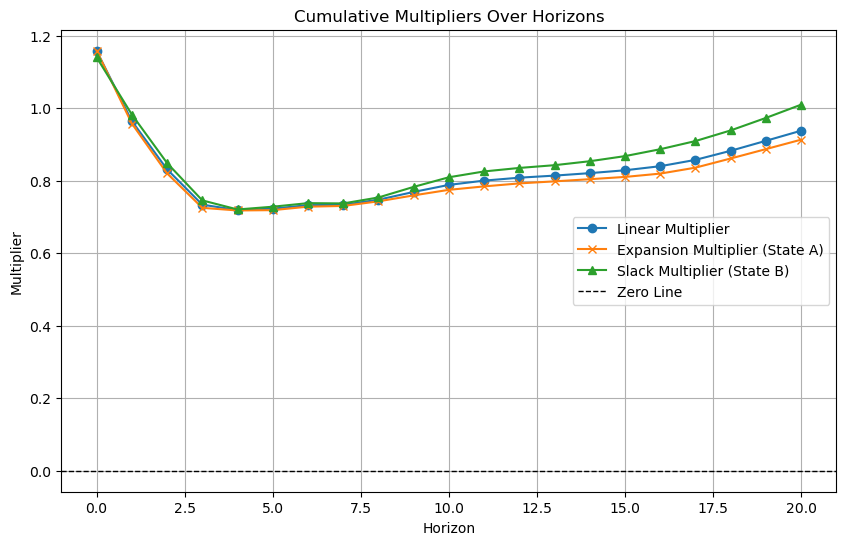

Length of multiplier_A: 21
Length of multiplier_B: 21

Horizon: 2-year
  Linear:
    Integral: 0.7472
    SE: 0.3551
    95% CI: (0.05115940913710071, 1.443250077004067)
    HAC p-value: 0.0354
  State A:
    Integral: 0.7428
    SE: 0.3118
    95% CI: (0.13171399636887982, 1.3538222565003675)
    HAC p-value: 0.0172
  State B:
    Integral: 0.7534
    SE: 0.6250
    95% CI: (-0.47152857289661754, 1.9784080308932737)
    HAC p-value: 0.2280

Horizon: 4-year
  Linear:
    Integral: 0.8397
    SE: 0.4347
    95% CI: (-0.012283625529596498, 1.6916613902390742)
    HAC p-value: 0.0534
  State A:
    Integral: 0.8192
    SE: 0.4114
    95% CI: (0.012867956510558165, 1.6256307039340876)
    HAC p-value: 0.0465
  State B:
    Integral: 0.8865
    SE: 1.1193
    95% CI: (-1.3074047833338036, 3.080420184084685)
    HAC p-value: 0.4284


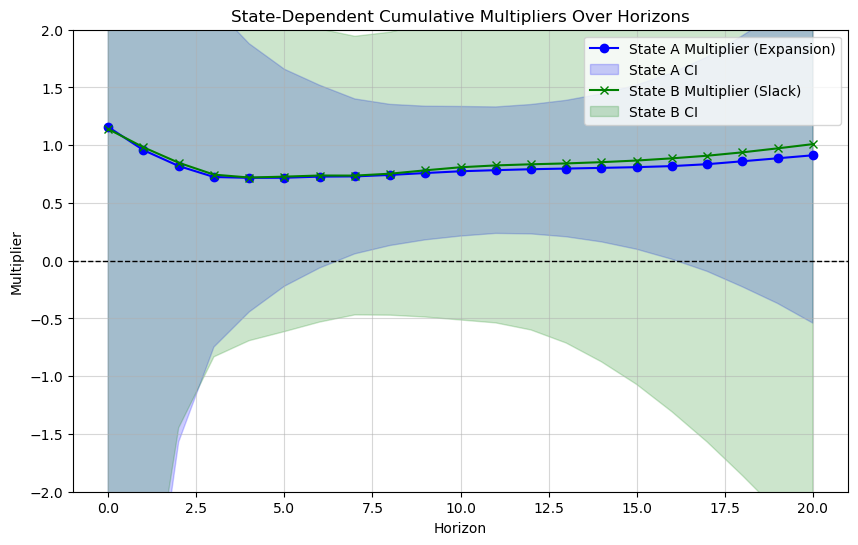

In [16]:
# Initialize lists to store results
linear_coeffs = []
state_dependent_coeffs_A = []
state_dependent_coeffs_B = []

horizons = np.arange(21)  # Horizons from 0 to 20

# Add lagged variables to the data
data['lag1_y'] = data['y'].shift(1)
data['lag2_y'] = data['y'].shift(2)
data['lag1_g'] = data['g'].shift(1)
data['lag2_g'] = data['g'].shift(2)
data['lag3_y'] = data['y'].shift(3)
data['lag4_y'] = data['y'].shift(4)
data['lag4_g'] = data['g'].shift(4)
data['lag3_g'] = data['g'].shift(3)

# Local Projection Loop
for h in horizons:
    print(f"\nPerforming Local Projection for Horizon {h}:")
    
    # Compute cumulative sums of dependent variables over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}
    
    # Build the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum,
        data[['newsy', 'slack', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
              'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
              'time', 'time_squared', 'time_cubed', 'time_quartic']]
    ], axis=1).dropna()
    
    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        linear_coeffs.append(np.nan)
        state_dependent_coeffs_A.append(np.nan)
        state_dependent_coeffs_B.append(np.nan)
        continue

    # Linear regression case (no state-dependence)
    try:
        X_linear = sm.add_constant(regression_data[['newsy', 'g_sum', 
                                                    'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                                    'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                                    'time', 'time_squared', 'time_cubed', 'time_quartic']])
        model_linear = sm.OLS(regression_data['y_sum'], X_linear).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
        linear_coeffs.append((model_linear.params['newsy'], model_linear.bse['newsy'],
                              model_linear.params['g_sum'], model_linear.bse['g_sum']))
    except Exception as e:
        print(f"Horizon {h}: Linear regression failed. {e}")
        linear_coeffs.append(np.nan)

    # State-dependent regression
    try:
        # Add state-dependent interactions
        regression_data['state_A'] = regression_data['slack']
        regression_data['state_B'] = 1 - regression_data['slack']
        regression_data['state_A_newsy'] = regression_data['newsy'] * regression_data['state_A']
        regression_data['state_B_newsy'] = regression_data['newsy'] * regression_data['state_B']
        regression_data['state_A_g_sum'] = regression_data['g_sum'] * regression_data['state_A']
        regression_data['state_B_g_sum'] = regression_data['g_sum'] * regression_data['state_B']

        # Build the regression model for state-dependent effects
        X_state = sm.add_constant(regression_data[['state_A_newsy', 'state_B_newsy', 
                                                   'state_A_g_sum', 'state_B_g_sum',
                                                   'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                                   'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                                   'time', 'time_squared', 'time_cubed', 'time_quartic']])
        model_state = sm.OLS(regression_data['y_sum'], X_state).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
        
        # Store coefficients
        state_dependent_coeffs_A.append((model_state.params['state_A_newsy'], model_state.bse['state_A_newsy'],
                                         model_state.params['state_A_g_sum'], model_state.bse['state_A_g_sum']))
        state_dependent_coeffs_B.append((model_state.params['state_B_newsy'], model_state.bse['state_B_newsy'],
                                         model_state.params['state_B_g_sum'], model_state.bse['state_B_g_sum']))
    except Exception as e:
        print(f"Horizon {h}: State-dependent regression failed. {e}")
        state_dependent_coeffs_A.append(np.nan)
        state_dependent_coeffs_B.append(np.nan)


# In[73]:


import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

# Initialize lists to store results
cumulative_multipliers = []
cumulative_standard_errors = []
horizons = np.arange(21)  # Horizons from 0 to 20

# Add lagged variables to the data (if not already added)
data['lag1_y'] = data['y'].shift(1)
data['lag2_y'] = data['y'].shift(2)
data['lag1_g'] = data['g'].shift(1)
data['lag2_g'] = data['g'].shift(2)

for h in horizons:
    print(f"\nEstimating Cumulative Multiplier for Horizon {h}:")

    # Compute cumulative sums over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}

    # Prepare the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum, data[['newsy', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                            'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                            'time', 'time_squared', 'time_cubed', 'time_quartic']]
    ], axis=1).dropna()

    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        cumulative_multipliers.append(np.nan)
        cumulative_standard_errors.append(np.nan)
        continue

    # Define the dependent and independent variables
    y = regression_data['y_sum']
    X = sm.add_constant(regression_data[['g_sum', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])
    Z = sm.add_constant(regression_data[['newsy', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])  # Instruments
    
    # Perform IV estimation
    try:
        iv_model = IV2SLS(y, X, instrument=Z).fit()
        
        # Calculate HAC robust standard errors manually
        hac_cov = sm.stats.sandwich_covariance.cov_hac(iv_model)
        hac_se = np.sqrt(np.diag(hac_cov))
        
        # Extract multiplier and standard error for g_sum
        cumulative_multiplier = iv_model.params['g_sum']  # Coefficient of g_sum
        cumulative_multiplier_se = hac_se[X.columns.get_loc('g_sum')]  # Robust SE for g_sum
        
        cumulative_multipliers.append(cumulative_multiplier)
        cumulative_standard_errors.append(cumulative_multiplier_se)

        print(f"Horizon {h}: Cumulative Multiplier = {cumulative_multiplier:.4f} (SE = {cumulative_multiplier_se:.4f})")
    except Exception as e:
        print(f"Horizon {h}: IV regression failed. {e}")
        cumulative_multipliers.append(np.nan)
        cumulative_standard_errors.append(np.nan)

# Save results to DataFrames
results_df = pd.DataFrame({
    'Horizon': horizons,
    'Multiplier': cumulative_multipliers,
    'Standard_Error': cumulative_standard_errors
})

# Save to CSV files
results_df[['Horizon', 'Multiplier']].to_csv("multipliers.csv", index=False)
results_df[['Horizon', 'Standard_Error']].to_csv("standard_errors.csv", index=False)

# Display the results
print("\nCumulative Multipliers (Horizon-by-Horizon):")
print(results_df)


# In[ ]:





# In[74]:


import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

# Initialize lists to store results
state_dependent_multipliers_A = []  # State A multipliers
state_dependent_multipliers_B = []  # State B multipliers
horizons = np.arange(21)  # Horizons from 0 to 20

# Add lagged variables to the data (if not already added)
data['lag1_y'] = data['y'].shift(1)
data['lag2_y'] = data['y'].shift(2)
data['lag1_g'] = data['g'].shift(1)
data['lag2_g'] = data['g'].shift(2)

for h in horizons:
    print(f"\nEstimating State-Dependent Cumulative Multipliers for Horizon {h}:")

    # Compute cumulative sums over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}

    # Prepare the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum, data[['newsy', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                            'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                            'time', 'time_squared', 'time_cubed', 'time_quartic', 'slack']]
    ], axis=1).dropna()

    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        state_dependent_multipliers_A.append(np.nan)
        state_dependent_multipliers_B.append(np.nan)
        continue

    # Define the dependent variable
    y = regression_data['y_sum']

    # Define state-dependent interaction terms
    regression_data['state_A'] = regression_data['slack']
    regression_data['state_B'] = 1 - regression_data['slack']
    regression_data['state_A_g_sum'] = regression_data['g_sum'] * regression_data['state_A']
    regression_data['state_B_g_sum'] = regression_data['g_sum'] * regression_data['state_B']
    regression_data['state_A_newsy'] = regression_data['newsy'] * regression_data['state_A']
    regression_data['state_B_newsy'] = regression_data['newsy'] * regression_data['state_B']

    # Define the independent variables (X) and instruments (Z)
    X = sm.add_constant(regression_data[['state_A_g_sum', 'state_B_g_sum', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])
    Z = sm.add_constant(regression_data[['state_A_newsy', 'state_B_newsy', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g', 
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])  # Instruments

    # Perform IV estimation
    try:
        iv_model = IV2SLS(y, X, instrument=Z).fit()
        
        # Calculate HAC robust standard errors manually
        hac_cov = sm.stats.sandwich_covariance.cov_hac(iv_model)
        hac_se = np.sqrt(np.diag(hac_cov))
        
        # Extract multipliers for state A and state B
        multiplier_A = iv_model.params['state_A_g_sum']
        multiplier_A_se = hac_se[X.columns.get_loc('state_A_g_sum')]
        multiplier_B = iv_model.params['state_B_g_sum']
        multiplier_B_se = hac_se[X.columns.get_loc('state_B_g_sum')]

        state_dependent_multipliers_A.append((multiplier_A, multiplier_A_se))
        state_dependent_multipliers_B.append((multiplier_B, multiplier_B_se))

        print(f"Horizon {h}: State A Multiplier = {multiplier_A:.4f} (SE = {multiplier_A_se:.4f})")
        print(f"Horizon {h}: State B Multiplier = {multiplier_B:.4f} (SE = {multiplier_B_se:.4f})")
    except Exception as e:
        print(f"Horizon {h}: IV regression failed. {e}")
        state_dependent_multipliers_A.append(np.nan)
        state_dependent_multipliers_B.append(np.nan)

# Display the results
print("\nState-Dependent Cumulative Multipliers (Horizon-by-Horizon):")
for h, (multiplier_A, multiplier_B) in enumerate(zip(state_dependent_multipliers_A, state_dependent_multipliers_B)):
    print(f"Horizon {h}: State A Multiplier = {multiplier_A}, State B Multiplier = {multiplier_B}")



# In[75]:
    
    
    
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

# Initialize lists to store results
state_dependent_multipliers_A = []  # State A multipliers
state_dependent_multipliers_B = []  # State B multipliers
state_dependent_se_A = []           # State A standard errors
state_dependent_se_B = []           # State B standard errors
horizons = np.arange(21)  # Horizons from 0 to 20

# Add lagged variables to the data (if not already added)
data['lag1_y'] = data['y'].shift(1)
data['lag2_y'] = data['y'].shift(2)
data['lag1_g'] = data['g'].shift(1)
data['lag2_g'] = data['g'].shift(2)

for h in horizons:
    print(f"\nEstimating State-Dependent Cumulative Multipliers for Horizon {h}:")

    # Compute cumulative sums over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}

    # Prepare the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum, data[['newsy', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                            'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                            'time', 'time_squared', 'time_cubed', 'time_quartic', 'slack']]
    ], axis=1).dropna()

    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        state_dependent_multipliers_A.append(np.nan)
        state_dependent_multipliers_B.append(np.nan)
        state_dependent_se_A.append(np.nan)
        state_dependent_se_B.append(np.nan)
        continue

    # Define the dependent variable
    y = regression_data['y_sum']

    # Define state-dependent interaction terms
    regression_data['state_A'] = regression_data['slack']
    regression_data['state_B'] = 1 - regression_data['slack']
    regression_data['state_A_g_sum'] = regression_data['g_sum'] * regression_data['state_A']
    regression_data['state_B_g_sum'] = regression_data['g_sum'] * regression_data['state_B']
    regression_data['state_A_newsy'] = regression_data['newsy'] * regression_data['state_A']
    regression_data['state_B_newsy'] = regression_data['newsy'] * regression_data['state_B']

    # Define the independent variables (X) and instruments (Z)
    X = sm.add_constant(regression_data[['state_A_g_sum', 'state_B_g_sum', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g', 
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])
    Z = sm.add_constant(regression_data[['state_A_newsy', 'state_B_newsy', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])  # Instruments

    # Perform IV estimation
    try:
        iv_model = IV2SLS(y, X, instrument=Z).fit()
        
        # Calculate HAC robust standard errors manually
        hac_cov = sm.stats.sandwich_covariance.cov_hac(iv_model)
        hac_se = np.sqrt(np.diag(hac_cov))
        
        # Extract multipliers for state A and state B
        multiplier_A = iv_model.params['state_A_g_sum']
        multiplier_A_se = hac_se[X.columns.get_loc('state_A_g_sum')]
        multiplier_B = iv_model.params['state_B_g_sum']
        multiplier_B_se = hac_se[X.columns.get_loc('state_B_g_sum')]

        state_dependent_multipliers_A.append(multiplier_A)
        state_dependent_se_A.append(multiplier_A_se)
        state_dependent_multipliers_B.append(multiplier_B)
        state_dependent_se_B.append(multiplier_B_se)

        print(f"Horizon {h}: State A Multiplier = {multiplier_A:.4f} (SE = {multiplier_A_se:.4f})")
        print(f"Horizon {h}: State B Multiplier = {multiplier_B:.4f} (SE = {multiplier_B_se:.4f})")
    except Exception as e:
        print(f"Horizon {h}: IV regression failed. {e}")
        state_dependent_multipliers_A.append(np.nan)
        state_dependent_se_A.append(np.nan)
        state_dependent_multipliers_B.append(np.nan)
        state_dependent_se_B.append(np.nan)

# Save results to DataFrames
results_A = pd.DataFrame({
    'Horizon': horizons,
    'Multiplier_A': state_dependent_multipliers_A,
    'Standard_Error_A': state_dependent_se_A
})

results_B = pd.DataFrame({
    'Horizon': horizons,
    'Multiplier_B': state_dependent_multipliers_B,
    'Standard_Error_B': state_dependent_se_B
})

# Save to CSV files
results_A.to_csv("state_dependent_multipliers_A.csv", index=False)
results_B.to_csv("state_dependent_multipliers_B.csv", index=False)

# Display the results
print("\nState-Dependent Cumulative Multipliers (Horizon-by-Horizon):")
print(results_A)
print(results_B)

    
    


# In[75]:
    # Initialize lists to store multipliers for each horizon
multiplier_A = []  # State A multipliers
multiplier_B = []  # State B multipliers

# Loop over horizons
for h in horizons:
    print(f"\nEstimating State-Dependent Cumulative Multipliers for Horizon {h}:")

    # Compute cumulative sums over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}

    # Prepare the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum, data[['newsy', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                            'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                            'time', 'time_squared', 'time_cubed', 'time_quartic', 'slack']]
    ], axis=1).dropna()

    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        state_dependent_multipliers_A.append(np.nan)
        state_dependent_multipliers_B.append(np.nan)
        state_dependent_se_A.append(np.nan)
        state_dependent_se_B.append(np.nan)
        continue


    # Define the dependent variable
    y = regression_data['y_sum']

    # Define state-dependent interaction terms
    regression_data['state_A'] = regression_data['slack']
    regression_data['state_B'] = 1 - regression_data['slack']
    regression_data['state_A_g_sum'] = regression_data['g_sum'] * regression_data['state_A']
    regression_data['state_B_g_sum'] = regression_data['g_sum'] * regression_data['state_B']
    regression_data['state_A_newsy'] = regression_data['newsy'] * regression_data['state_A']
    regression_data['state_B_newsy'] = regression_data['newsy'] * regression_data['state_B']

    # Define the independent variables (X) and instruments (Z)
    X = sm.add_constant(regression_data[['state_A_g_sum', 'state_B_g_sum', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g', 
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])
    Z = sm.add_constant(regression_data[['state_A_newsy', 'state_B_newsy', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g', 
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])  # Instruments

    # Perform IV estimation
    try:
        iv_model = IV2SLS(y, X, instrument=Z).fit()
        
        # Calculate HAC robust standard errors manually
        hac_cov = sm.stats.sandwich_covariance.cov_hac(iv_model)
        hac_se = np.sqrt(np.diag(hac_cov))
        
        # Extract multipliers for state A and state B
        state_A_multiplier = iv_model.params['state_A_g_sum']
        state_A_se = hac_se[X.columns.get_loc('state_A_g_sum')]
        state_B_multiplier = iv_model.params['state_B_g_sum']
        state_B_se = hac_se[X.columns.get_loc('state_B_g_sum')]

        # Append results to lists
        multiplier_A.append((state_A_multiplier, state_A_se))
        multiplier_B.append((state_B_multiplier, state_B_se))

        print(f"Horizon {h}: State A Multiplier = {state_A_multiplier:.4f} (SE = {state_A_se:.4f})")
        print(f"Horizon {h}: State B Multiplier = {state_B_multiplier:.4f} (SE = {state_B_se:.4f})")
    except Exception as e:
        print(f"Horizon {h}: IV regression failed. {e}")
        multiplier_A.append(np.nan)
        multiplier_B.append(np.nan)

# Display the results
print("\nState-Dependent Cumulative Multipliers (Horizon-by-Horizon):")
for h, (state_A, state_B) in enumerate(zip(multiplier_A, multiplier_B)):
    print(f"Horizon {h}: State A Multiplier = {state_A}, State B Multiplier = {state_B}")

    
    
    
    

import pandas as pd
import matplotlib.pyplot as plt

# Convert results to a DataFrame for easy handling
df_multipliers = pd.DataFrame({
    'Horizon': horizons,
    'Linear': cumulative_multipliers,
    'State A': state_dependent_multipliers_A,
    'State B': state_dependent_multipliers_B
})

# Save the DataFrame to a CSV file
df_multipliers.to_csv("cumulative_multipliers_plot_data.csv", index=False)

# Plot the cumulative multipliers
plt.figure(figsize=(10, 6))

# Plot the linear multiplier
plt.plot(df_multipliers['Horizon'], df_multipliers['Linear'], label='Linear Multiplier', marker='o')

# Plot the state-dependent multipliers
plt.plot(df_multipliers['Horizon'], df_multipliers['State A'], label='Expansion Multiplier (State A)', marker='x')
plt.plot(df_multipliers['Horizon'], df_multipliers['State B'], label='Slack Multiplier (State B)', marker='^')

# Add details to the plot
plt.axhline(0, color='black', linestyle='--', linewidth=1, label="Zero Line")
plt.title('Cumulative Multipliers Over Horizons')
plt.xlabel('Horizon')
plt.ylabel('Multiplier')
plt.legend(loc='best')
plt.grid()

# Display the plot
plt.show()


# In[76]:

    
##

print(f"Length of multiplier_A: {len(multiplier_A)}")
print(f"Length of multiplier_B: {len(multiplier_B)}")

##


from scipy.stats import norm
import numpy as np

# Define horizons for integration
integration_horizons = {'2-year': 8, '4-year': 16}

# Initialize results container
results = []

# Extract SEs and multipliers for Linear, State A, and State B
linear_se = cumulative_standard_errors
state_A_multipliers = [m[0] if isinstance(m, tuple) else np.nan for m in multiplier_A]
state_A_se = [m[1] if isinstance(m, tuple) else np.nan for m in multiplier_A]
state_B_multipliers = [m[0] if isinstance(m, tuple) else np.nan for m in multiplier_B]
state_B_se = [m[1] if isinstance(m, tuple) else np.nan for m in multiplier_B]

# Loop through integration horizons
for label, max_horizon in integration_horizons.items():
    if max_horizon >= len(horizons):
        print(f"Not enough data for {label}. Skipping...")
        continue

    # Fetch values for the max_horizon
    linear_integral = cumulative_multipliers[max_horizon]
    state_A_integral = state_A_multipliers[max_horizon]
    state_B_integral = state_B_multipliers[max_horizon]

    linear_integral_se = linear_se[max_horizon]
    state_A_integral_se = state_A_se[max_horizon]
    state_B_integral_se = state_B_se[max_horizon]

    # Compute confidence intervals
    linear_ci = (linear_integral - 1.96 * linear_integral_se, linear_integral + 1.96 * linear_integral_se)
    state_A_ci = (state_A_integral - 1.96 * state_A_integral_se, state_A_integral + 1.96 * state_A_integral_se)
    state_B_ci = (state_B_integral - 1.96 * state_B_integral_se, state_B_integral + 1.96 * state_B_integral_se)

    # Compute HAC p-values
    linear_hac_p = 2 * (1 - norm.cdf(abs(linear_integral / linear_integral_se)))
    state_A_hac_p = 2 * (1 - norm.cdf(abs(state_A_integral / state_A_integral_se)))
    state_B_hac_p = 2 * (1 - norm.cdf(abs(state_B_integral / state_B_integral_se)))

    # Append results
    results.append({
        'Horizon': label,
        'Linear': {
            'Integral': linear_integral, 'SE': linear_integral_se,
            'CI': linear_ci, 'HAC p-value': linear_hac_p
        },
        'State A': {
            'Integral': state_A_integral, 'SE': state_A_integral_se,
            'CI': state_A_ci, 'HAC p-value': state_A_hac_p
        },
        'State B': {
            'Integral': state_B_integral, 'SE': state_B_integral_se,
            'CI': state_B_ci, 'HAC p-value': state_B_hac_p
        }
    })

# Display results
for res in results:
    print(f"\nHorizon: {res['Horizon']}")
    for key in ['Linear', 'State A', 'State B']:
        print(f"  {key}:")
        print(f"    Integral: {res[key]['Integral']:.4f}")
        print(f"    SE: {res[key]['SE']:.4f}")
        print(f"    95% CI: {res[key]['CI']}")
        print(f"    HAC p-value: {res[key]['HAC p-value']:.4f}")



# Extract multipliers and standard errors for State A and State B
horizons = np.arange(21)

# State A multipliers and SE
state_A_multipliers = [m[0] if isinstance(m, tuple) and len(m) > 1 else np.nan for m in multiplier_A]
state_A_se = [m[1] if isinstance(m, tuple) and len(m) > 1 else np.nan for m in multiplier_A]

# State B multipliers and SE
state_B_multipliers = [m[0] if isinstance(m, tuple) and len(m) > 1 else np.nan for m in multiplier_B]
state_B_se = [m[1] if isinstance(m, tuple) and len(m) > 1 else np.nan for m in multiplier_B]

# Compute confidence intervals
state_A_upper = np.array(state_A_multipliers) + 1.96 * np.array(state_A_se)
state_A_lower = np.array(state_A_multipliers) - 1.96 * np.array(state_A_se)

state_B_upper = np.array(state_B_multipliers) + 1.96 * np.array(state_B_se)
state_B_lower = np.array(state_B_multipliers) - 1.96 * np.array(state_B_se)

# Convert results to a DataFrame for easy handling
df_multipliers = pd.DataFrame({
    'Horizon': horizons,
    'State A': state_A_multipliers,
    'State A Upper': state_A_upper,
    'State A Lower': state_A_lower,
    'State B': state_B_multipliers,
    'State B Upper': state_B_upper,
    'State B Lower': state_B_lower
})

# Save DataFrame to CSV
df_multipliers.to_csv("state_dependent_multipliers_with_ci.csv", index=False)

# Plot the state-dependent multipliers with confidence intervals
plt.figure(figsize=(10, 6))

# State A multipliers
plt.plot(df_multipliers['Horizon'], df_multipliers['State A'], label='State A Multiplier (Expansion)', marker='o', color='blue')
plt.fill_between(df_multipliers['Horizon'], df_multipliers['State A Lower'], df_multipliers['State A Upper'],
                 color='blue', alpha=0.2, label='State A CI')

# State B multipliers
plt.plot(df_multipliers['Horizon'], df_multipliers['State B'], label='State B Multiplier (Slack)', marker='x', color='green')
plt.fill_between(df_multipliers['Horizon'], df_multipliers['State B Lower'], df_multipliers['State B Upper'],
                 color='green', alpha=0.2, label='State B CI')

# Add details to the plot
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('State-Dependent Cumulative Multipliers Over Horizons')
plt.xlabel('Horizon')
plt.ylabel('Multiplier')

# Adjust the y-axis range to zoom in
plt.ylim(-2, 2)  # Adjust based on the range you want to zoom into

# Enhance grid and legend visibility
plt.grid(alpha=0.5)
plt.legend()
plt.show()




## BP as a shock


Performing Local Projection for Horizon 0:

Performing Local Projection for Horizon 1:

Performing Local Projection for Horizon 2:

Performing Local Projection for Horizon 3:

Performing Local Projection for Horizon 4:

Performing Local Projection for Horizon 5:

Performing Local Projection for Horizon 6:

Performing Local Projection for Horizon 7:

Performing Local Projection for Horizon 8:

Performing Local Projection for Horizon 9:

Performing Local Projection for Horizon 10:

Performing Local Projection for Horizon 11:

Performing Local Projection for Horizon 12:

Performing Local Projection for Horizon 13:

Performing Local Projection for Horizon 14:

Performing Local Projection for Horizon 15:

Performing Local Projection for Horizon 16:

Performing Local Projection for Horizon 17:

Performing Local Projection for Horizon 18:

Performing Local Projection for Horizon 19:

Performing Local Projection for Horizon 20:

Estimating Cumulative Multiplier for Horizon 0:
Horizon 0: Cumul

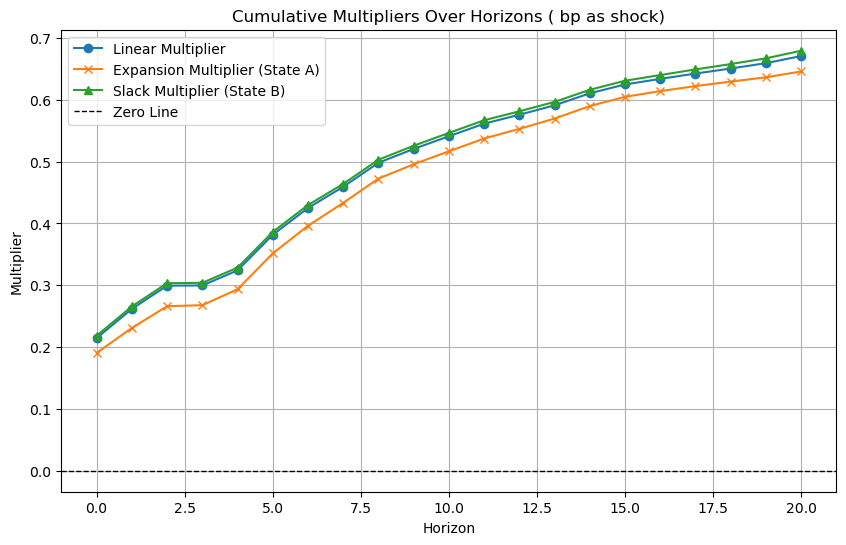

Length of multiplier_A: 21
Length of multiplier_B: 21

Horizon: 2-year
  Linear:
    Integral: 0.4981
    SE: 0.3153
    95% CI: (-0.11987304229479945, 1.1159912375711092)
    HAC p-value: 0.1142
  State A:
    Integral: 0.4725
    SE: 1.5074
    95% CI: (0.012867956510558165, 1.6256307039340876)
    HAC p-value: 0.7539
  State B:
    Integral: 0.5030
    SE: 7.3353
    95% CI: (-13.87415712721701, 14.880183659204366)
    HAC p-value: 0.9453

Horizon: 4-year
  Linear:
    Integral: 0.6337
    SE: 0.9031
    95% CI: (-1.13641502780826, 2.403887391663326)
    HAC p-value: 0.4829
  State A:
    Integral: 0.6140
    SE: 1.5074
    95% CI: (0.012867956510558165, 1.6256307039340876)
    HAC p-value: 0.6838
  State B:
    Integral: 0.6400
    SE: 7.3353
    95% CI: (-13.73719416885823, 15.017146617563148)
    HAC p-value: 0.9305


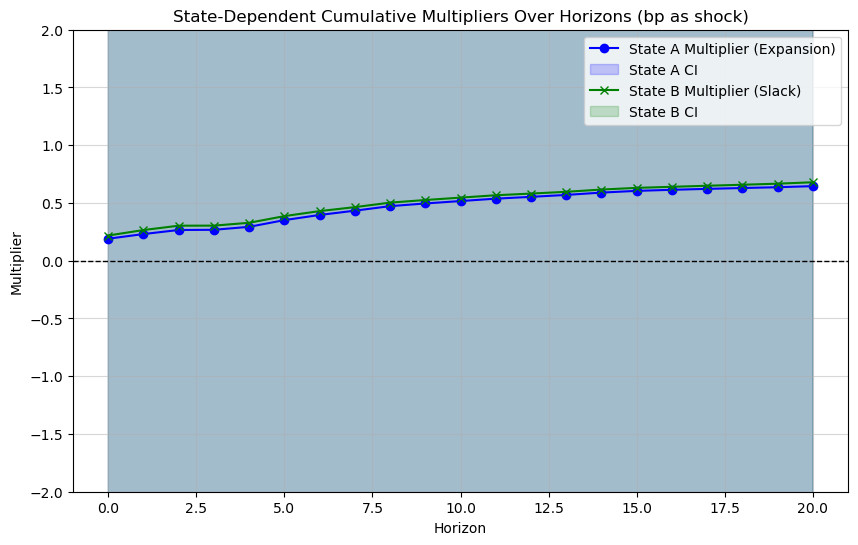

In [32]:
# Initialize lists to store results
linear_coeffs_bp = []
state_dependent_coeffs_A_bp = []
state_dependent_coeffs_B_bp = []

horizons = np.arange(21)  # Horizons from 0 to 20

# Add lagged variables to the data
data['lag1_y'] = data['y'].shift(1)
data['lag2_y'] = data['y'].shift(2)
data['lag1_g'] = data['g'].shift(1)
data['lag2_g'] = data['g'].shift(2)
data['lag3_y'] = data['y'].shift(3)
data['lag4_y'] = data['y'].shift(4)
data['lag4_g'] = data['g'].shift(4)
data['lag3_g'] = data['g'].shift(3)

# Local Projection Loop
for h in horizons:
    print(f"\nPerforming Local Projection for Horizon {h}:")
    
    # Compute cumulative sums of dependent variables over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}
    
    # Build the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum,
        data[['bp', 'slack', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
              'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
              'time', 'time_squared', 'time_cubed', 'time_quartic']]
    ], axis=1).dropna()
    
    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        linear_coeffs.append(np.nan)
        state_dependent_coeffs_A_bp.append(np.nan)
        state_dependent_coeffs_B_bp.append(np.nan)
        continue

    # Linear regression case (no state-dependence)
    try:
        X_linear = sm.add_constant(regression_data[['bp', 'g_sum', 
                                                    'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                                    'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                                    'time', 'time_squared', 'time_cubed', 'time_quartic']])
        model_linear = sm.OLS(regression_data['y_sum'], X_linear).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
        linear_coeffs_bp.append((model_linear.params['bp'], model_linear.bse['bp'],
                              model_linear.params['g_sum'], model_linear.bse['g_sum']))
    except Exception as e:
        print(f"Horizon {h}: Linear regression failed. {e}")
        linear_coeffs.append(np.nan)

    # State-dependent regression
    try:
        # Add state-dependent interactions
        regression_data['state_A_bp'] = regression_data['slack']
        regression_data['state_B_bp'] = 1 - regression_data['slack']
        regression_data['state_A_bp'] = regression_data['bp'] * regression_data['state_A_bp']
        regression_data['state_B_bp'] = regression_data['bp'] * regression_data['state_B_bp']
        regression_data['state_A_g_sum_bp'] = regression_data['g_sum'] * regression_data['state_A_bp']
        regression_data['state_B_g_sum_bp'] = regression_data['g_sum'] * regression_data['state_B_bp']

        # Build the regression model for state-dependent effects
        X_state = sm.add_constant(regression_data[['state_A_bp', 'state_B_bp', 
                                                   'state_A_g_sum_bp', 'state_B_g_sum_bp',
                                                   'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                                   'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                                   'time', 'time_squared', 'time_cubed', 'time_quartic']])
        model_state = sm.OLS(regression_data['y_sum'], X_state).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
        
        # Store coefficients
        state_dependent_coeffs_A_bp.append((model_state.params['state_A_bp'], model_state.bse['state_A_bp'],
                                         model_state.params['state_A_g_sum_bp'], model_state.bse['state_A_g_sum_bp']))
        state_dependent_coeffs_B_bp.append((model_state.params['state_B_bp'], model_state.bse['state_B_bp'],
                                         model_state.params['state_B_g_sum_bp'], model_state.bse['state_B_g_sum_bp']))
    except Exception as e:
        print(f"Horizon {h}: State-dependent regression failed. {e}")
        state_dependent_coeffs_A_bp.append(np.nan)
        state_dependent_coeffs_B_bp.append(np.nan)


# In[73]:


import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

# Initialize lists to store results
cumulative_multipliers_bp = []
cumulative_standard_errors_bp = []
horizons = np.arange(21)  # Horizons from 0 to 20

# Add lagged variables to the data (if not already added)
data['lag1_y'] = data['y'].shift(1)
data['lag2_y'] = data['y'].shift(2)
data['lag1_g'] = data['g'].shift(1)
data['lag2_g'] = data['g'].shift(2)

for h in horizons:
    print(f"\nEstimating Cumulative Multiplier for Horizon {h}:")

    # Compute cumulative sums over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}

    # Prepare the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum, data[['bp', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                            'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                            'time', 'time_squared', 'time_cubed', 'time_quartic']]
    ], axis=1).dropna()

    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        cumulative_multipliers_bp.append(np.nan)
        cumulative_standard_errors_bp.append(np.nan)
        continue

    # Define the dependent and independent variables
    y = regression_data['y_sum']
    X = sm.add_constant(regression_data[['g_sum', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])
    Z = sm.add_constant(regression_data[['bp', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])  # Instruments
    
    # Perform IV estimation
    try:
        iv_model = IV2SLS(y, X, instrument=Z).fit()
        
        # Calculate HAC robust standard errors manually
        hac_cov = sm.stats.sandwich_covariance.cov_hac(iv_model)
        hac_se = np.sqrt(np.diag(hac_cov))
        
        # Extract multiplier and standard error for g_sum
        cumulative_multiplier_bp = iv_model.params['g_sum']  # Coefficient of g_sum
        cumulative_multiplier_se_bp = hac_se[X.columns.get_loc('g_sum')]  # Robust SE for g_sum
        
        cumulative_multipliers_bp.append(cumulative_multiplier_bp)
        cumulative_standard_errors_bp.append(cumulative_multiplier_se_bp)

        print(f"Horizon {h}: Cumulative Multiplier = {cumulative_multiplier_bp:.4f} (SE = {cumulative_multiplier_se_bp:.4f})")
    except Exception as e:
        print(f"Horizon {h}: IV regression failed. {e}")
        cumulative_multipliers_bp.append(np.nan)
        cumulative_standard_errors_bp.append(np.nan)

# Save results to DataFrames
results_df_bp = pd.DataFrame({
    'Horizon': horizons,
    'Multiplier_bp': cumulative_multipliers_bp,
    'Standard_Error_bp': cumulative_standard_errors_bp
})

# Save to CSV files
results_df_bp[['Horizon', 'Multiplier_bp']].to_csv("multipliers_bp.csv", index=False)
results_df_bp[['Horizon', 'Standard_Error_bp']].to_csv("standard_errors_bp.csv", index=False)

# Display the results
print("\nCumulative Multipliers (Horizon-by-Horizon):")
print(results_df_bp)


# In[ ]:





# In[74]:

# Initialize lists to store results
state_dependent_multipliers_A_bp = []  # State A multipliers
state_dependent_multipliers_B_bp = []  # State B multipliers
horizons = np.arange(21)  # Horizons from 0 to 20

# Add lagged variables to the data (if not already added)
data['lag1_y'] = data['y'].shift(1)
data['lag2_y'] = data['y'].shift(2)
data['lag1_g'] = data['g'].shift(1)
data['lag2_g'] = data['g'].shift(2)

for h in horizons:
    print(f"\nEstimating State-Dependent Cumulative Multipliers for Horizon {h}:")

    # Compute cumulative sums over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}

    # Prepare the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum, data[['bp', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                            'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                            'time', 'time_squared', 'time_cubed', 'time_quartic', 'slack']]
    ], axis=1).dropna()

    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        state_dependent_multipliers_A_bp.append(np.nan)
        state_dependent_multipliers_B_bp.append(np.nan)
        continue

    # Define the dependent variable
    y = regression_data['y_sum']

    # Define state-dependent interaction terms
    regression_data['state_A_bp'] = regression_data['slack']
    regression_data['state_B_bp'] = 1 - regression_data['slack']
    regression_data['state_A_g_sum_bp'] = regression_data['g_sum'] * regression_data['state_A_bp']
    regression_data['state_B_g_sum_bp'] = regression_data['g_sum'] * regression_data['state_B_bp']
    regression_data['state_A_bp'] = regression_data['bp'] * regression_data['state_A_bp']
    regression_data['state_B_bp'] = regression_data['bp'] * regression_data['state_B_bp']

    # Define the independent variables (X) and instruments (Z)
    X = sm.add_constant(regression_data[['state_A_g_sum_bp', 'state_B_g_sum_bp', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])
    Z = sm.add_constant(regression_data[['state_A_bp', 'state_B_bp', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g', 
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])  # Instruments

    # Perform IV estimation
    try:
        iv_model = IV2SLS(y, X, instrument=Z).fit()
        
        # Calculate HAC robust standard errors manually
        hac_cov_bp = sm.stats.sandwich_covariance.cov_hac(iv_model)
        hac_se_bp = np.sqrt(np.diag(hac_cov))
        
        # Extract multipliers for state A and state B
        multiplier_A_bp = iv_model.params['state_A_g_sum_bp']
        multiplier_A_se_bp = hac_se[X.columns.get_loc('state_A_g_sum_bp')]
        multiplier_B_bp = iv_model.params['state_B_g_sum_bp']
        multiplier_B_se_bp = hac_se[X.columns.get_loc('state_B_g_sum_bp')]

        state_dependent_multipliers_A_bp.append((multiplier_A_bp, multiplier_A_se_bp))
        state_dependent_multipliers_B_bp.append((multiplier_B_bp, multiplier_B_se_bp))

        print(f"Horizon {h}: State A Multiplier = {multiplier_A_bp:.4f} (SE = {multiplier_A_se_bp:.4f})")
        print(f"Horizon {h}: State B Multiplier = {multiplier_B_bp:.4f} (SE = {multiplier_B_se_bp:.4f})")
    except Exception as e:
        print(f"Horizon {h}: IV regression failed. {e}")
        state_dependent_multipliers_A_bp.append(np.nan)
        state_dependent_multipliers_B_bp.append(np.nan)

# Display the results
print("\nState-Dependent Cumulative Multipliers (Horizon-by-Horizon):")
for h, (multiplier_A_bp, multiplier_B_bp) in enumerate(zip(state_dependent_multipliers_A_bp, state_dependent_multipliers_B_bp)):
    print(f"Horizon {h}: State A Multiplier = {multiplier_A_bp}, State B Multiplier = {multiplier_B_bp}")



# In[75]:
    

# Initialize lists to store results
state_dependent_multipliers_A_bp = []  # State A multipliers
state_dependent_multipliers_B_bp = []  # State B multipliers
state_dependent_se_A_bp = []           # State A standard errors
state_dependent_se_B_bp = []           # State B standard errors
horizons = np.arange(21)  # Horizons from 0 to 20


#state dependent IV

for h in horizons:
    print(f"\nEstimating State-Dependent Cumulative Multipliers for Horizon {h}:")

    # Compute cumulative sums over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}

    # Prepare the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum, data[['bp', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                            'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                            'time', 'time_squared', 'time_cubed', 'time_quartic', 'slack']]
    ], axis=1).dropna()

    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        state_dependent_multipliers_A_bp.append(np.nan)
        state_dependent_multipliers_B_bp.append(np.nan)
        state_dependent_se_A_bp.append(np.nan)
        state_dependent_se_B_bp.append(np.nan)
        continue

    # Define the dependent variable
    y = regression_data['y_sum']

    # Define state-dependent interaction terms
    regression_data['state_A_bp'] = regression_data['slack']
    regression_data['state_B_bp'] = 1 - regression_data['slack']
    regression_data['state_A_g_sum_bp'] = regression_data['g_sum'] * regression_data['state_A_bp']
    regression_data['state_B_g_sum_bp'] = regression_data['g_sum'] * regression_data['state_B_bp']
    regression_data['state_A_bp'] = regression_data['bp'] * regression_data['state_A_bp']
    regression_data['state_B_bp'] = regression_data['bp'] * regression_data['state_B_bp']

    # Define the independent variables (X) and instruments (Z)
    X = sm.add_constant(regression_data[['state_A_g_sum_bp', 'state_B_g_sum_bp', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g', 
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])
    Z = sm.add_constant(regression_data[['state_A_bp', 'state_B_bp', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])  # Instruments

    # Perform IV estimation
    try:
        iv_model = IV2SLS(y, X, instrument=Z).fit()
        
        # Calculate HAC robust standard errors manually
        hac_cov_bp = sm.stats.sandwich_covariance.cov_hac(iv_model)
        hac_se_bp = np.sqrt(np.diag(hac_cov))
        
        # Extract multipliers for state A and state B
        multiplier_A_bp = iv_model.params['state_A_g_sum_bp']
        multiplier_A_se_bp = hac_se[X.columns.get_loc('state_A_g_sum_bp')]
        multiplier_B_bp = iv_model.params['state_B_g_sum_bp']
        multiplier_B_se_bp = hac_se[X.columns.get_loc('state_B_g_sum_bp')]

        state_dependent_multipliers_A_bp.append(multiplier_A_bp)
        state_dependent_se_A_bp.append(multiplier_A_se_bp)
        state_dependent_multipliers_B_bp.append(multiplier_B_bp)
        state_dependent_se_B_bp.append(multiplier_B_se_bp)

        print(f"Horizon {h}: State A Multiplier = {multiplier_A_bp:.4f} (SE = {multiplier_A_se_bp:.4f})")
        print(f"Horizon {h}: State B Multiplier = {multiplier_B_bp:.4f} (SE = {multiplier_B_se_bp:.4f})")
    except Exception as e:
        print(f"Horizon {h}: IV regression failed. {e}")
        state_dependent_multipliers_A_bp.append(np.nan)
        state_dependent_se_A_bp.append(np.nan)
        state_dependent_multipliers_B_bp.append(np.nan)
        state_dependent_se_B_bp.append(np.nan)

# Save results to DataFrames
results_A_bp = pd.DataFrame({
    'Horizon': horizons,
    'Multiplier_A_bp': state_dependent_multipliers_A_bp,
    'Standard_Error_A_bp': state_dependent_se_A_bp
})

results_B_bp = pd.DataFrame({
    'Horizon': horizons,
    'Multiplier_B_bp': state_dependent_multipliers_B_bp,
    'Standard_Error_B_bp': state_dependent_se_B_bp
})

# Save to CSV files
results_A_bp.to_csv("state_dependent_multipliers_A_bp.csv", index=False)
results_B_bp.to_csv("state_dependent_multipliers_B_bp.csv", index=False)

# Display the results
print("\nState-Dependent Cumulative Multipliers (Horizon-by-Horizon):")
print(results_A_bp)
print(results_B_bp)

    
    


# In[75]:
    # Initialize lists to store multipliers for each horizon
multiplier_A_bp = []  # State A multipliers
multiplier_B_bp = []  # State B multipliers

# Loop over horizons
for h in horizons:
    print(f"\nEstimating State-Dependent Cumulative Multipliers for Horizon {h}:")

    # Compute cumulative sums over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}

    # Prepare the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum, data[['bp', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                            'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                            'time', 'time_squared', 'time_cubed', 'time_quartic', 'slack']]
    ], axis=1).dropna()

    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        state_dependent_multipliers_A_bp.append(np.nan)
        state_dependent_multipliers_B_bp.append(np.nan)
        state_dependent_se_A_bp.append(np.nan)
        state_dependent_se_B_bp.append(np.nan)
        continue


    # Define the dependent variable
    y = regression_data['y_sum']

    # Define state-dependent interaction terms
    regression_data['state_A_bp'] = regression_data['slack']
    regression_data['state_B_bp'] = 1 - regression_data['slack']
    regression_data['state_A_g_sum_bp'] = regression_data['g_sum'] * regression_data['state_A_bp']
    regression_data['state_B_g_sum_bp'] = regression_data['g_sum'] * regression_data['state_B_bp']
    regression_data['state_A_bp'] = regression_data['bp'] * regression_data['state_A_bp']
    regression_data['state_B_bp'] = regression_data['bp'] * regression_data['state_B_bp']

    # Define the independent variables (X) and instruments (Z)
    X = sm.add_constant(regression_data[['state_A_g_sum_bp', 'state_B_g_sum_bp', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g', 
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])
    Z = sm.add_constant(regression_data[['state_A_bp', 'state_B_bp', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g', 
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])  # Instruments

    # Perform IV estimation
    try:
        iv_model = IV2SLS(y, X, instrument=Z).fit()
        
        # Calculate HAC robust standard errors manually
        hac_cov_bp = sm.stats.sandwich_covariance.cov_hac(iv_model)
        hac_se_bp = np.sqrt(np.diag(hac_cov_bp))
        
        # Extract multipliers for state A and state B
        state_A_multiplier_bp = iv_model.params['state_A_g_sum_bp']
        state_A_se_bp = hac_se[X.columns.get_loc('state_A_g_sum_bp')]
        state_B_multiplier_bp = iv_model.params['state_B_g_sum_bp']
        state_B_se_bp = hac_se[X.columns.get_loc('state_B_g_sum_bp')]

        # Append results to lists
        multiplier_A_bp.append((state_A_multiplier_bp, state_A_se_bp))
        multiplier_B_bp.append((state_B_multiplier_bp, state_B_se_bp))

        print(f"Horizon {h}: State A Multiplier = {state_A_multiplier_bp:.4f} (SE = {state_A_se_bp:.4f})")
        print(f"Horizon {h}: State B Multiplier = {state_B_multiplier_bp:.4f} (SE = {state_B_se_bp:.4f})")
    except Exception as e:
        print(f"Horizon {h}: IV regression failed. {e}")
        multiplier_A_bp.append(np.nan)
        multiplier_B_bp.append(np.nan)

# Display the results
print("\nState-Dependent Cumulative Multipliers (Horizon-by-Horizon):")
for h, (state_A_bp, state_B_bp) in enumerate(zip(multiplier_A_bp, multiplier_B_bp)):
    print(f"Horizon {h}: State A Multiplier = {state_A_bp}, State B Multiplier = {state_B_bp}")

    
    

# Convert results to a DataFrame for easy handling
df_multipliers_bp = pd.DataFrame({
    'Horizon': horizons,
    'Linear': cumulative_multipliers_bp,
    'State A': state_dependent_multipliers_A_bp,
    'State B': state_dependent_multipliers_B_bp
})

# Save the DataFrame to a CSV file
df_multipliers_bp.to_csv("cumulative_multipliers_bp_plot_data_bp.csv", index=False)

# Plot the cumulative multipliers
plt.figure(figsize=(10, 6))

# Plot the linear multiplier
plt.plot(df_multipliers_bp['Horizon'], df_multipliers_bp['Linear'], label='Linear Multiplier', marker='o')

# Plot the state-dependent multipliers
plt.plot(df_multipliers_bp['Horizon'], df_multipliers_bp['State A'], label='Expansion Multiplier (State A)', marker='x')
plt.plot(df_multipliers_bp['Horizon'], df_multipliers_bp['State B'], label='Slack Multiplier (State B)', marker='^')

# Add details to the plot
plt.axhline(0, color='black', linestyle='--', linewidth=1, label="Zero Line")
plt.title('Cumulative Multipliers Over Horizons ( bp as shock)')
plt.xlabel('Horizon')
plt.ylabel('Multiplier')
plt.legend(loc='best')
plt.grid()

# Display the plot
plt.show()


# In[76]:

    
##

print(f"Length of multiplier_A: {len(multiplier_A_bp)}")
print(f"Length of multiplier_B: {len(multiplier_B_bp)}")

##


from scipy.stats import norm
import numpy as np

# Define horizons for integration
integration_horizons = {'2-year': 8, '4-year': 16}

# Initialize results container
results_bp = []

# Extract SEs and multipliers for Linear, State A, and State B
linear_se_bp = cumulative_standard_errors_bp
state_A_multipliers_bp = [m[0] if isinstance(m, tuple) else np.nan for m in multiplier_A_bp]
state_A_se_bp = [m[1] if isinstance(m, tuple) else np.nan for m in multiplier_A_bp]
state_B_multipliers_bp = [m[0] if isinstance(m, tuple) else np.nan for m in multiplier_B_bp]
state_B_se_bp = [m[1] if isinstance(m, tuple) else np.nan for m in multiplier_B_bp]

# Loop through integration horizons
for label, max_horizon in integration_horizons.items():
    if max_horizon >= len(horizons):
        print(f"Not enough data for {label}. Skipping...")
        continue

    # Fetch values for the max_horizon
    linear_integral_bp = cumulative_multipliers_bp[max_horizon]
    state_A_integral_bp = state_A_multipliers_bp[max_horizon]
    state_B_integral_bp = state_B_multipliers_bp[max_horizon]

    linear_integral_se_bp = linear_se_bp[max_horizon]
    state_A_integral_se_bp = state_A_se_bp[max_horizon]
    state_B_integral_se_bp = state_B_se_bp[max_horizon]

    # Compute confidence intervals
    linear_ci_bp = (linear_integral_bp - 1.96 * linear_integral_se_bp, linear_integral_bp + 1.96 * linear_integral_se_bp)
    state_A_ci_bp = (state_A_integral_bp - 1.96 * state_A_integral_se_bp, state_A_integral_bp + 1.96 * state_A_integral_se_bp)
    state_B_ci_bp = (state_B_integral_bp - 1.96 * state_B_integral_se_bp, state_B_integral_bp + 1.96 * state_B_integral_se_bp)

    # Compute HAC p-values
    linear_hac_p_bp = 2 * (1 - norm.cdf(abs(linear_integral_bp/ linear_integral_se_bp)))
    state_A_hac_p_bp = 2 * (1 - norm.cdf(abs(state_A_integral_bp / state_A_integral_se_bp)))
    state_B_hac_p_bp = 2 * (1 - norm.cdf(abs(state_B_integral_bp / state_B_integral_se_bp)))

    # Append results
    results_bp.append({
        'Horizon': label,
        'Linear': {
            'Integral': linear_integral_bp, 'SE': linear_integral_se_bp,
            'CI': linear_ci_bp, 'HAC p-value': linear_hac_p_bp
        },
        'State A': {
            'Integral': state_A_integral_bp, 'SE': state_A_integral_se_bp,
            'CI': state_A_ci, 'HAC p-value': state_A_hac_p_bp
        },
        'State B': {
            'Integral': state_B_integral_bp, 'SE': state_B_integral_se_bp,
            'CI': state_B_ci_bp, 'HAC p-value': state_B_hac_p_bp
        }
    })

# Display results
for res in results_bp:
    print(f"\nHorizon: {res['Horizon']}")
    for key in ['Linear', 'State A', 'State B']:
        print(f"  {key}:")
        print(f"    Integral: {res[key]['Integral']:.4f}")
        print(f"    SE: {res[key]['SE']:.4f}")
        print(f"    95% CI: {res[key]['CI']}")
        print(f"    HAC p-value: {res[key]['HAC p-value']:.4f}")



# Extract multipliers and standard errors for State A and State B
horizons = np.arange(21)

# State A multipliers and SE
state_A_multipliers_bp = [m[0] if isinstance(m, tuple) and len(m) > 1 else np.nan for m in multiplier_A_bp]
state_A_se_bp = [m[1] if isinstance(m, tuple) and len(m) > 1 else np.nan for m in multiplier_A_bp]

# State B multipliers and SE
state_B_multipliers_bp = [m[0] if isinstance(m, tuple) and len(m) > 1 else np.nan for m in multiplier_B_bp]
state_B_se_bp = [m[1] if isinstance(m, tuple) and len(m) > 1 else np.nan for m in multiplier_B_bp]

# Compute confidence intervals
state_A_upper_bp = np.array(state_A_multipliers_bp) + 1.96 * np.array(state_A_se_bp)
state_A_lower_bp = np.array(state_A_multipliers_bp) - 1.96 * np.array(state_A_se_bp)

state_B_upper_bp = np.array(state_B_multipliers_bp) + 1.96 * np.array(state_B_se_bp)
state_B_lower_bp = np.array(state_B_multipliers_bp) - 1.96 * np.array(state_B_se_bp)

# Convert results to a DataFrame for easy handling
df_multipliers_bp = pd.DataFrame({
    'Horizon': horizons,
    'State A': state_A_multipliers_bp,
    'State A Upper': state_A_upper_bp,
    'State A Lower': state_A_lower_bp,
    'State B': state_B_multipliers_bp,
    'State B Upper': state_B_upper_bp,
    'State B Lower': state_B_lower_bp
})

# Save DataFrame to CSV
df_multipliers_bp.to_csv("state_dependent_multipliers_with_ci_bp.csv", index=False)

# Plot the state-dependent multipliers with confidence intervals
plt.figure(figsize=(10, 6))

# State A multipliers
plt.plot(df_multipliers_bp['Horizon'], df_multipliers_bp['State A'], label='State A Multiplier (Expansion)', marker='o', color='blue')
plt.fill_between(df_multipliers_bp['Horizon'], df_multipliers_bp['State A Lower'], df_multipliers_bp['State A Upper'],
                 color='blue', alpha=0.2, label='State A CI')

# State B multipliers
plt.plot(df_multipliers_bp['Horizon'], df_multipliers_bp['State B'], label='State B Multiplier (Slack)', marker='x', color='green')
plt.fill_between(df_multipliers_bp['Horizon'], df_multipliers_bp['State B Lower'], df_multipliers_bp['State B Upper'],
                 color='green', alpha=0.2, label='State B CI')

# Add details to the plot
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('State-Dependent Cumulative Multipliers Over Horizons (bp as shock)')
plt.xlabel('Horizon')
plt.ylabel('Multiplier')

# Adjust the y-axis range to zoom in
plt.ylim(-2, 2)  # Adjust based on the range you want to zoom into

# Enhance grid and legend visibility
plt.grid(alpha=0.5)
plt.legend()
plt.show()





Projection locale pour Horizon 0:

Projection locale pour Horizon 1:

Projection locale pour Horizon 2:

Projection locale pour Horizon 3:

Projection locale pour Horizon 4:

Projection locale pour Horizon 5:

Projection locale pour Horizon 6:

Projection locale pour Horizon 7:

Projection locale pour Horizon 8:

Projection locale pour Horizon 9:

Projection locale pour Horizon 10:

Projection locale pour Horizon 11:

Projection locale pour Horizon 12:

Projection locale pour Horizon 13:

Projection locale pour Horizon 14:

Projection locale pour Horizon 15:

Projection locale pour Horizon 16:

Projection locale pour Horizon 17:

Projection locale pour Horizon 18:

Projection locale pour Horizon 19:

Projection locale pour Horizon 20:


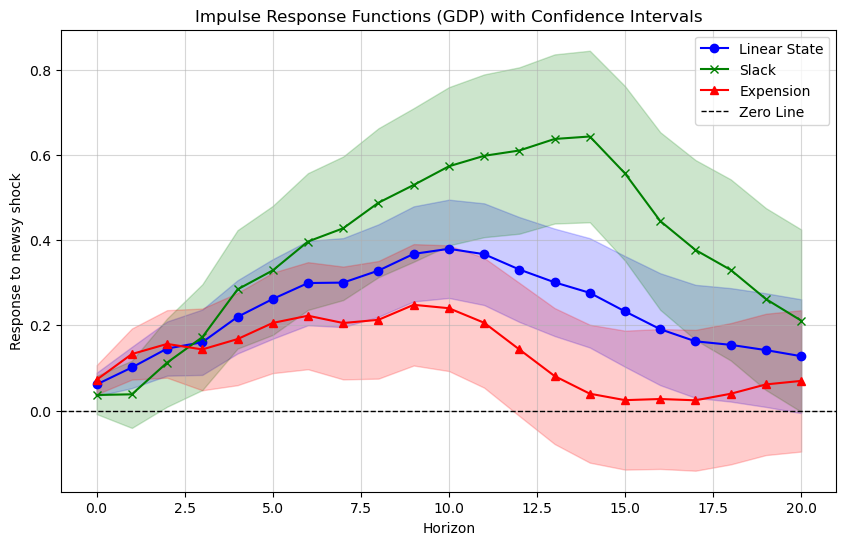

In [48]:
#IRF computatioin
horizons = np.arange(21)


irf_linear = [] 
irf_linear_se = [] 

irf_slack = [] 
irf_slack_se = []  

irf_non_slack = []  
irf_non_slack_se = [] 


for h in horizons:
    print(f"\nProjection locale pour Horizon {h}:")
    

    y_h = data['y'].shift(-h)
    

    regression_data = pd.concat([
        y_h.rename('y_h'),
        data['newsy'],  # Choc
        data[['lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
              'time', 'time_squared', 'time_cubed', 'time_quartic', 'slack']]
    ], axis=1).dropna()
    
    if regression_data.empty:
        print(f"Horizon {h}: Pas de données disponibles.")
        irf_linear.append(np.nan)
        irf_linear_se.append(np.nan)
        irf_slack.append(np.nan)
        irf_slack_se.append(np.nan)
        irf_non_slack.append(np.nan)
        irf_non_slack_se.append(np.nan)
        continue
    

    X_linear = sm.add_constant(regression_data[['newsy', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                                'time', 'time_squared', 'time_cubed', 'time_quartic']])
    y = regression_data['y_h']
    model_linear = sm.OLS(y, X_linear).fit()
    irf_linear.append(model_linear.params['newsy'])
    irf_linear_se.append(model_linear.bse['newsy'])

 
    regression_data['state_A_newsy'] = regression_data['newsy'] * regression_data['slack']
    regression_data['state_B_newsy'] = regression_data['newsy'] * (1 - regression_data['slack'])


    X_slack = sm.add_constant(regression_data[['state_A_newsy', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                               'time', 'time_squared', 'time_cubed', 'time_quartic']])
    model_slack = sm.OLS(y, X_slack).fit()
    irf_slack.append(model_slack.params['state_A_newsy'])
    irf_slack_se.append(model_slack.bse['state_A_newsy'])


    X_non_slack = sm.add_constant(regression_data[['state_B_newsy', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                                   'time', 'time_squared', 'time_cubed', 'time_quartic']])
    model_non_slack = sm.OLS(y, X_non_slack).fit()
    irf_non_slack.append(model_non_slack.params['state_B_newsy'])
    irf_non_slack_se.append(model_non_slack.bse['state_B_newsy'])


plt.figure(figsize=(10, 6))


irf_linear = np.array(irf_linear)
irf_linear_se = np.array(irf_linear_se)
plt.plot(horizons, irf_linear, marker='o', label='Linear State', color='blue')
plt.fill_between(horizons, irf_linear - 1.96 * irf_linear_se, irf_linear + 1.96 * irf_linear_se, 
                 color='blue', alpha=0.2)


irf_slack = np.array(irf_slack)
irf_slack_se = np.array(irf_slack_se)
plt.plot(horizons, irf_slack, marker='x', label='Slack', color='green')
plt.fill_between(horizons, irf_slack - 1.96 * irf_slack_se, irf_slack + 1.96 * irf_slack_se, 
                 color='green', alpha=0.2)


irf_non_slack = np.array(irf_non_slack)
irf_non_slack_se = np.array(irf_non_slack_se)
plt.plot(horizons, irf_non_slack, marker='^', label='Expension', color='red')
plt.fill_between(horizons, irf_non_slack - 1.96 * irf_non_slack_se, irf_non_slack + 1.96 * irf_non_slack_se, 
                 color='red', alpha=0.2)


plt.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero Line')
plt.title('Impulse Response Functions (GDP) with Confidence Intervals')
plt.xlabel('Horizon')
plt.ylabel('Response to newsy shock')
plt.legend(loc='best')
plt.grid(alpha=0.5)


plt.show()



Projection locale pour Horizon 0 (Gov Spending):

Projection locale pour Horizon 1 (Gov Spending):

Projection locale pour Horizon 2 (Gov Spending):

Projection locale pour Horizon 3 (Gov Spending):

Projection locale pour Horizon 4 (Gov Spending):

Projection locale pour Horizon 5 (Gov Spending):

Projection locale pour Horizon 6 (Gov Spending):

Projection locale pour Horizon 7 (Gov Spending):

Projection locale pour Horizon 8 (Gov Spending):

Projection locale pour Horizon 9 (Gov Spending):

Projection locale pour Horizon 10 (Gov Spending):

Projection locale pour Horizon 11 (Gov Spending):

Projection locale pour Horizon 12 (Gov Spending):

Projection locale pour Horizon 13 (Gov Spending):

Projection locale pour Horizon 14 (Gov Spending):

Projection locale pour Horizon 15 (Gov Spending):

Projection locale pour Horizon 16 (Gov Spending):

Projection locale pour Horizon 17 (Gov Spending):

Projection locale pour Horizon 18 (Gov Spending):

Projection locale pour Horizon 19 (Gov S

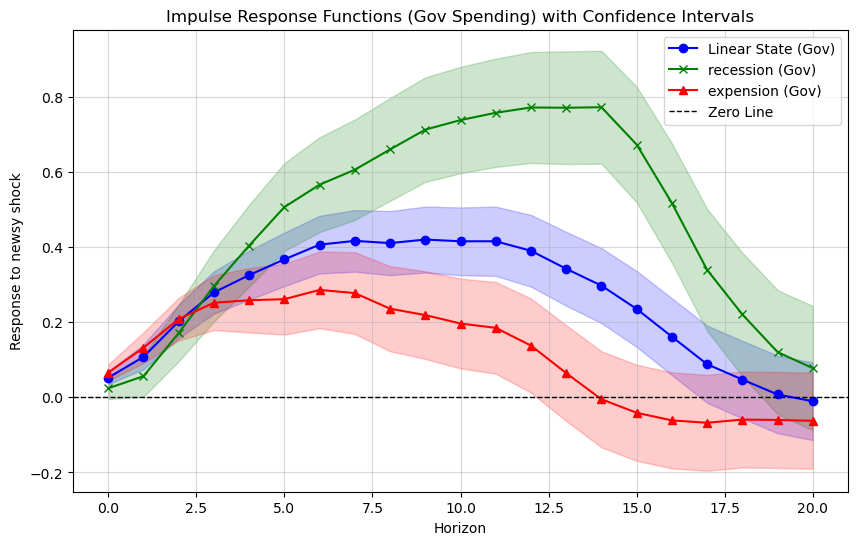

In [49]:

horizons = np.arange(21)


irf_linear_gov = []  
irf_linear_gov_se = [] 

irf_slack_gov = [] 
irf_slack_gov_se = [] 

irf_non_slack_gov = []
irf_non_slack_gov_se = [] 


for h in horizons:
    print(f"\nProjection locale pour Horizon {h} (Gov Spending):")
    
   
    g_h = data['g'].shift(-h)
    
   
    regression_data = pd.concat([
        g_h.rename('g_h'),
        data['newsy'],  # Choc
        data[['lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
              'time', 'time_squared', 'time_cubed', 'time_quartic', 'slack']]
    ], axis=1).dropna()
    
    if regression_data.empty:
        print(f"Horizon {h}: Pas de données disponibles pour gov spending.")
        irf_linear_gov.append(np.nan)
        irf_linear_gov_se.append(np.nan)
        irf_slack_gov.append(np.nan)
        irf_slack_gov_se.append(np.nan)
        irf_non_slack_gov.append(np.nan)
        irf_non_slack_gov_se.append(np.nan)
        continue
    
  
    X_linear = sm.add_constant(regression_data[['newsy', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                                'time', 'time_squared', 'time_cubed', 'time_quartic']])
    y = regression_data['g_h']
    model_linear = sm.OLS(y, X_linear).fit()
    irf_linear_gov.append(model_linear.params['newsy'])
    irf_linear_gov_se.append(model_linear.bse['newsy'])


    regression_data['state_A_newsy'] = regression_data['newsy'] * regression_data['slack']
    regression_data['state_B_newsy'] = regression_data['newsy'] * (1 - regression_data['slack'])


    X_slack = sm.add_constant(regression_data[['state_A_newsy', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                               'time', 'time_squared', 'time_cubed', 'time_quartic']])
    model_slack = sm.OLS(y, X_slack).fit()
    irf_slack_gov.append(model_slack.params['state_A_newsy'])
    irf_slack_gov_se.append(model_slack.bse['state_A_newsy'])


    X_non_slack = sm.add_constant(regression_data[['state_B_newsy', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                                   'time', 'time_squared', 'time_cubed', 'time_quartic']])
    model_non_slack = sm.OLS(y, X_non_slack).fit()
    irf_non_slack_gov.append(model_non_slack.params['state_B_newsy'])
    irf_non_slack_gov_se.append(model_non_slack.bse['state_B_newsy'])


plt.figure(figsize=(10, 6))


irf_linear_gov = np.array(irf_linear_gov)
irf_linear_gov_se = np.array(irf_linear_gov_se)
plt.plot(horizons, irf_linear_gov, marker='o', label='Linear State (Gov)', color='blue')
plt.fill_between(horizons, irf_linear_gov - 1.96 * irf_linear_gov_se, irf_linear_gov + 1.96 * irf_linear_gov_se, 
                 color='blue', alpha=0.2)


irf_slack_gov = np.array(irf_slack_gov)
irf_slack_gov_se = np.array(irf_slack_gov_se)
plt.plot(horizons, irf_slack_gov, marker='x', label='recession (Gov)', color='green')
plt.fill_between(horizons, irf_slack_gov - 1.96 * irf_slack_gov_se, irf_slack_gov + 1.96 * irf_slack_gov_se, 
                 color='green', alpha=0.2)


irf_non_slack_gov = np.array(irf_non_slack_gov)
irf_non_slack_gov_se = np.array(irf_non_slack_gov_se)
plt.plot(horizons, irf_non_slack_gov, marker='^', label='expension (Gov)', color='red')
plt.fill_between(horizons, irf_non_slack_gov - 1.96 * irf_non_slack_gov_se, irf_non_slack_gov + 1.96 * irf_non_slack_gov_se, 
                 color='red', alpha=0.2)


plt.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero Line')
plt.title('Impulse Response Functions (Gov Spending) with Confidence Intervals')
plt.xlabel('Horizon')
plt.ylabel('Response to newsy shock')
plt.legend(loc='best')
plt.grid(alpha=0.5)


plt.show()


## Combined instruments

In [35]:
data['comb'] = data['newsy'].fillna(0) + data['bp'].fillna(0)


Performing Local Projection for Horizon 0:

Performing Local Projection for Horizon 1:

Performing Local Projection for Horizon 2:

Performing Local Projection for Horizon 3:

Performing Local Projection for Horizon 4:

Performing Local Projection for Horizon 5:

Performing Local Projection for Horizon 6:

Performing Local Projection for Horizon 7:

Performing Local Projection for Horizon 8:

Performing Local Projection for Horizon 9:

Performing Local Projection for Horizon 10:

Performing Local Projection for Horizon 11:

Performing Local Projection for Horizon 12:

Performing Local Projection for Horizon 13:

Performing Local Projection for Horizon 14:

Performing Local Projection for Horizon 15:

Performing Local Projection for Horizon 16:

Performing Local Projection for Horizon 17:

Performing Local Projection for Horizon 18:

Performing Local Projection for Horizon 19:

Performing Local Projection for Horizon 20:

Estimating Cumulative Multiplier for Horizon 0:
Horizon 0: Cumul

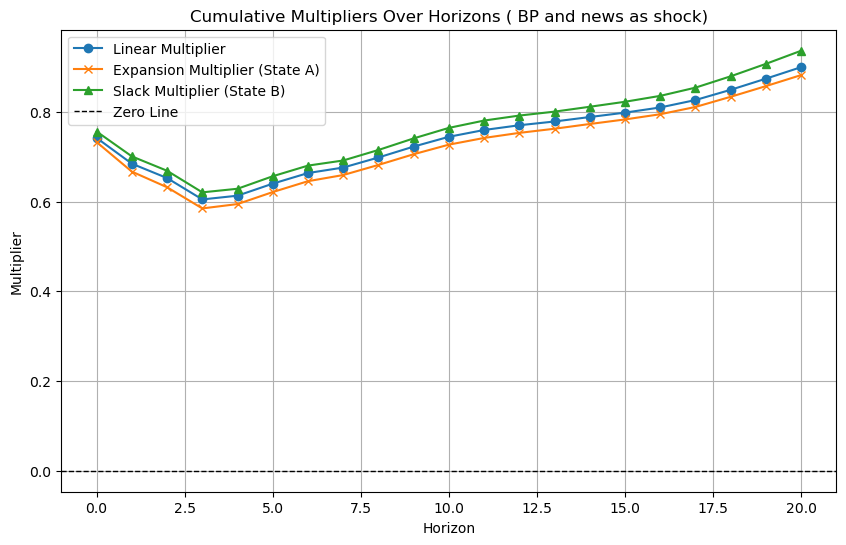

Length of multiplier_A: 21
Length of multiplier_B: 21

Horizon: 2-year
  Linear:
    Integral: 0.6985
    SE: 0.2366
    95% CI: (0.23471843407134896, 1.162315508352144)
    HAC p-value: 0.0032
  State A:
    Integral: 0.6819
    SE: 0.5912
    95% CI: (-0.47688416900850594, 1.8407104817667328)
    HAC p-value: 0.2487
  State B:
    Integral: 0.7152
    SE: 3.5425
    95% CI: (-6.2280005235225575, 7.658488818909647)
    HAC p-value: 0.8400

Horizon: 4-year
  Linear:
    Integral: 0.8101
    SE: 0.3567
    95% CI: (0.1108953856245326, 1.5092499948702756)
    HAC p-value: 0.0232
  State A:
    Integral: 0.7949
    SE: 0.5912
    95% CI: (-0.36385740868380667, 1.953737242091432)
    HAC p-value: 0.1788
  State B:
    Integral: 0.8359
    SE: 3.5425
    95% CI: (-6.107345992730494, 7.779143349701711)
    HAC p-value: 0.8135


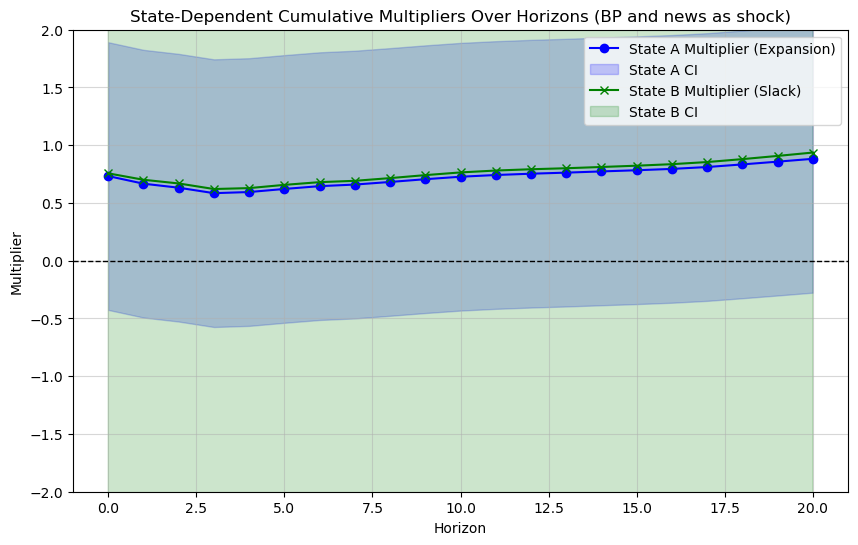

In [41]:
# Initialize lists to store results
linear_coeffs_comb = []
state_dependent_coeffs_A_comb = []
state_dependent_coeffs_B_comb = []

horizons = np.arange(21)  # Horizons from 0 to 20

# Add lagged variables to the data
data['lag1_y'] = data['y'].shift(1)
data['lag2_y'] = data['y'].shift(2)
data['lag1_g'] = data['g'].shift(1)
data['lag2_g'] = data['g'].shift(2)
data['lag3_y'] = data['y'].shift(3)
data['lag4_y'] = data['y'].shift(4)
data['lag4_g'] = data['g'].shift(4)
data['lag3_g'] = data['g'].shift(3)

# Local Projection Loop
for h in horizons:
    print(f"\nPerforming Local Projection for Horizon {h}:")
    
    # Compute cumulative sums of dependent variables over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}
    
    # Build the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum,
        data[['comb', 'slack', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
              'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
              'time', 'time_squared', 'time_cubed', 'time_quartic']]
    ], axis=1).dropna()
    
    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        linear_coeffs.append(np.nan)
        state_dependent_coeffs_A_comb.append(np.nan)
        state_dependent_coeffs_B_comb.append(np.nan)
        continue

    # Linear regression case (no state-dependence)
    try:
        X_linear = sm.add_constant(regression_data[['comb', 'g_sum', 
                                                    'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                                    'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                                    'time', 'time_squared', 'time_cubed', 'time_quartic']])
        model_linear = sm.OLS(regression_data['y_sum'], X_linear).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
        linear_coeffs_comb.append((model_linear.params['comb'], model_linear.bse['comb'],
                              model_linear.params['g_sum'], model_linear.bse['g_sum']))
    except Exception as e:
        print(f"Horizon {h}: Linear regression failed. {e}")
        linear_coeffs.append(np.nan)

    # State-dependent regression
    try:
        # Add state-dependent interactions
        regression_data['state_A_comb'] = regression_data['slack']
        regression_data['state_B_comb'] = 1 - regression_data['slack']
        regression_data['state_A_comb'] = regression_data['comb'] * regression_data['state_A_comb']
        regression_data['state_B_comb'] = regression_data['comb'] * regression_data['state_B_comb']
        regression_data['state_A_g_sum_comb'] = regression_data['g_sum'] * regression_data['state_A_comb']
        regression_data['state_B_g_sum_comb'] = regression_data['g_sum'] * regression_data['state_B_comb']

        # Build the regression model for state-dependent effects
        X_state = sm.add_constant(regression_data[['state_A_comb', 'state_B_comb', 
                                                   'state_A_g_sum_comb', 'state_B_g_sum_comb',
                                                   'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                                   'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                                   'time', 'time_squared', 'time_cubed', 'time_quartic']])
        model_state = sm.OLS(regression_data['y_sum'], X_state).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
        
        # Store coefficients
        state_dependent_coeffs_A_comb.append((model_state.params['state_A_comb'], model_state.bse['state_A_comb'],
                                         model_state.params['state_A_g_sum_comb'], model_state.bse['state_A_g_sum_comb']))
        state_dependent_coeffs_B_comb.append((model_state.params['state_B_comb'], model_state.bse['state_B_comb'],
                                         model_state.params['state_B_g_sum_comb'], model_state.bse['state_B_g_sum_comb']))
    except Exception as e:
        print(f"Horizon {h}: State-dependent regression failed. {e}")
        state_dependent_coeffs_A_comb.append(np.nan)
        state_dependent_coeffs_B_comb.append(np.nan)


# In[73]:


import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

# Initialize lists to store results
cumulative_multipliers_comb = []
cumulative_standard_errors_comb = []
horizons = np.arange(21)  # Horizons from 0 to 20

# Add lagged variables to the data (if not already added)
data['lag1_y'] = data['y'].shift(1)
data['lag2_y'] = data['y'].shift(2)
data['lag1_g'] = data['g'].shift(1)
data['lag2_g'] = data['g'].shift(2)

for h in horizons:
    print(f"\nEstimating Cumulative Multiplier for Horizon {h}:")

    # Compute cumulative sums over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}

    # Prepare the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum, data[['comb', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                            'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                            'time', 'time_squared', 'time_cubed', 'time_quartic']]
    ], axis=1).dropna()

    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        cumulative_multipliers_comb.append(np.nan)
        cumulative_standard_errors_comb.append(np.nan)
        continue

    # Define the dependent and independent variables
    y = regression_data['y_sum']
    X = sm.add_constant(regression_data[['g_sum', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])
    Z = sm.add_constant(regression_data[['comb', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])  # Instruments
    
    # Perform IV estimation
    try:
        iv_model = IV2SLS(y, X, instrument=Z).fit()
        
        # Calculate HAC robust standard errors manually
        hac_cov = sm.stats.sandwich_covariance.cov_hac(iv_model)
        hac_se = np.sqrt(np.diag(hac_cov))
        
        # Extract multiplier and standard error for g_sum
        cumulative_multiplier_comb = iv_model.params['g_sum']  # Coefficient of g_sum
        cumulative_multiplier_se_comb = hac_se[X.columns.get_loc('g_sum')]  # Robust SE for g_sum
        
        cumulative_multipliers_comb.append(cumulative_multiplier_comb)
        cumulative_standard_errors_comb.append(cumulative_multiplier_se_comb)

        print(f"Horizon {h}: Cumulative Multiplier = {cumulative_multiplier_comb:.4f} (SE = {cumulative_multiplier_se_comb:.4f})")
    except Exception as e:
        print(f"Horizon {h}: IV regression failed. {e}")
        cumulative_multipliers_comb.append(np.nan)
        cumulative_standard_errors_comb.append(np.nan)

# Save results to DataFrames
results_df_comb = pd.DataFrame({
    'Horizon': horizons,
    'Multiplier_comb': cumulative_multipliers_comb,
    'Standard_Error_comb': cumulative_standard_errors_comb
})

# Save to CSV files
results_df_comb[['Horizon', 'Multiplier_comb']].to_csv("multipliers_comb.csv", index=False)
results_df_comb[['Horizon', 'Standard_Error_comb']].to_csv("standard_errors_comb.csv", index=False)

# Display the results
print("\nCumulative Multipliers (Horizon-by-Horizon):")
print(results_df_comb)


# In[ ]:





# In[74]:

# Initialize lists to store results
state_dependent_multipliers_A_comb = []  # State A multipliers
state_dependent_multipliers_B_comb = []  # State B multipliers
horizons = np.arange(21)  # Horizons from 0 to 20

# Add lagged variables to the data (if not already added)
data['lag1_y'] = data['y'].shift(1)
data['lag2_y'] = data['y'].shift(2)
data['lag1_g'] = data['g'].shift(1)
data['lag2_g'] = data['g'].shift(2)

for h in horizons:
    print(f"\nEstimating State-Dependent Cumulative Multipliers for Horizon {h}:")

    # Compute cumulative sums over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}

    # Prepare the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum, data[['comb', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                            'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                            'time', 'time_squared', 'time_cubed', 'time_quartic', 'slack']]
    ], axis=1).dropna()

    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        state_dependent_multipliers_A_comb.append(np.nan)
        state_dependent_multipliers_B_comb.append(np.nan)
        continue

    # Define the dependent variable
    y = regression_data['y_sum']

    # Define state-dependent interaction terms
    regression_data['state_A_comb'] = regression_data['slack']
    regression_data['state_B_comb'] = 1 - regression_data['slack']
    regression_data['state_A_g_sum_comb'] = regression_data['g_sum'] * regression_data['state_A_comb']
    regression_data['state_B_g_sum_comb'] = regression_data['g_sum'] * regression_data['state_B_comb']
    regression_data['state_A_comb'] = regression_data['comb'] * regression_data['state_A_comb']
    regression_data['state_B_comb'] = regression_data['comb'] * regression_data['state_B_comb']

    # Define the independent variables (X) and instruments (Z)
    X = sm.add_constant(regression_data[['state_A_g_sum_comb', 'state_B_g_sum_comb', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])
    Z = sm.add_constant(regression_data[['state_A_comb', 'state_B_comb', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g', 
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])  # Instruments

    # Perform IV estimation
    try:
        iv_model = IV2SLS(y, X, instrument=Z).fit()
        
        # Calculate HAC robust standard errors manually
        hac_cov_comb = sm.stats.sandwich_covariance.cov_hac(iv_model)
        hac_se_comb = np.sqrt(np.diag(hac_cov))
        
        # Extract multipliers for state A and state B
        multiplier_A_comb = iv_model.params['state_A_g_sum_comb']
        multiplier_A_se_comb = hac_se[X.columns.get_loc('state_A_g_sum_comb')]
        multiplier_B_comb = iv_model.params['state_B_g_sum_comb']
        multiplier_B_se_comb = hac_se[X.columns.get_loc('state_B_g_sum_comb')]

        state_dependent_multipliers_A_comb.append((multiplier_A_comb, multiplier_A_se_comb))
        state_dependent_multipliers_B_comb.append((multiplier_B_comb, multiplier_B_se_comb))

        print(f"Horizon {h}: State A Multiplier = {multiplier_A_comb:.4f} (SE = {multiplier_A_se_comb:.4f})")
        print(f"Horizon {h}: State B Multiplier = {multiplier_B_comb:.4f} (SE = {multiplier_B_se_comb:.4f})")
    except Exception as e:
        print(f"Horizon {h}: IV regression failed. {e}")
        state_dependent_multipliers_A_comb.append(np.nan)
        state_dependent_multipliers_B_comb.append(np.nan)

# Display the results
print("\nState-Dependent Cumulative Multipliers (Horizon-by-Horizon):")
for h, (multiplier_A_comb, multiplier_B_comb) in enumerate(zip(state_dependent_multipliers_A_comb, state_dependent_multipliers_B_comb)):
    print(f"Horizon {h}: State A Multiplier = {multiplier_A_comb}, State B Multiplier = {multiplier_B_comb}")



# In[75]:
    

# Initialize lists to store results
state_dependent_multipliers_A_comb = []  # State A multipliers
state_dependent_multipliers_B_comb = []  # State B multipliers
state_dependent_se_A_comb = []           # State A standard errors
state_dependent_se_B_comb = []           # State B standard errors
horizons = np.arange(21)  # Horizons from 0 to 20


#state dependent IV

for h in horizons:
    print(f"\nEstimating State-Dependent Cumulative Multipliers for Horizon {h}:")

    # Compute cumulative sums over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}

    # Prepare the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum, data[['comb', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                            'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                            'time', 'time_squared', 'time_cubed', 'time_quartic', 'slack']]
    ], axis=1).dropna()

    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        state_dependent_multipliers_A_comb.append(np.nan)
        state_dependent_multipliers_B_comb.append(np.nan)
        state_dependent_se_A_comb.append(np.nan)
        state_dependent_se_B_comb.append(np.nan)
        continue

    # Define the dependent variable
    y = regression_data['y_sum']

    # Define state-dependent interaction terms
    regression_data['state_A_comb'] = regression_data['slack']
    regression_data['state_B_comb'] = 1 - regression_data['slack']
    regression_data['state_A_g_sum_comb'] = regression_data['g_sum'] * regression_data['state_A_comb']
    regression_data['state_B_g_sum_comb'] = regression_data['g_sum'] * regression_data['state_B_comb']
    regression_data['state_A_comb'] = regression_data['comb'] * regression_data['state_A_comb']
    regression_data['state_B_comb'] = regression_data['comb'] * regression_data['state_B_comb']

    # Define the independent variables (X) and instruments (Z)
    X = sm.add_constant(regression_data[['state_A_g_sum_comb', 'state_B_g_sum_comb', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g', 
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])
    Z = sm.add_constant(regression_data[['state_A_comb', 'state_B_comb', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])  # Instruments

    # Perform IV estimation
    try:
        iv_model = IV2SLS(y, X, instrument=Z).fit()
        
        # Calculate HAC robust standard errors manually
        hac_cov_comb = sm.stats.sandwich_covariance.cov_hac(iv_model)
        hac_se_comb = np.sqrt(np.diag(hac_cov))
        
        # Extract multipliers for state A and state B
        multiplier_A_comb = iv_model.params['state_A_g_sum_comb']
        multiplier_A_se_comb = hac_se[X.columns.get_loc('state_A_g_sum_comb')]
        multiplier_B_comb = iv_model.params['state_B_g_sum_comb']
        multiplier_B_se_comb = hac_se[X.columns.get_loc('state_B_g_sum_comb')]

        state_dependent_multipliers_A_comb.append(multiplier_A_comb)
        state_dependent_se_A_comb.append(multiplier_A_se_comb)
        state_dependent_multipliers_B_comb.append(multiplier_B_comb)
        state_dependent_se_B_comb.append(multiplier_B_se_comb)

        print(f"Horizon {h}: State A Multiplier = {multiplier_A_comb:.4f} (SE = {multiplier_A_se_comb:.4f})")
        print(f"Horizon {h}: State B Multiplier = {multiplier_B_comb:.4f} (SE = {multiplier_B_se_comb:.4f})")
    except Exception as e:
        print(f"Horizon {h}: IV regression failed. {e}")
        state_dependent_multipliers_A_comb.append(np.nan)
        state_dependent_se_A_comb.append(np.nan)
        state_dependent_multipliers_B_comb.append(np.nan)
        state_dependent_se_B_comb.append(np.nan)

# Save results to DataFrames
results_A_comb = pd.DataFrame({
    'Horizon': horizons,
    'Multiplier_A_comb': state_dependent_multipliers_A_comb,
    'Standard_Error_A_comb': state_dependent_se_A_comb
})

results_B_comb = pd.DataFrame({
    'Horizon': horizons,
    'Multiplier_B_comb': state_dependent_multipliers_B_comb,
    'Standard_Error_B_comb': state_dependent_se_B_comb
})

# Save to CSV files
results_A_comb.to_csv("state_dependent_multipliers_A_comb.csv", index=False)
results_B_comb.to_csv("state_dependent_multipliers_B_comb.csv", index=False)

# Display the results
print("\nState-Dependent Cumulative Multipliers (Horizon-by-Horizon):")
print(results_A_comb)
print(results_B_comb)

    
    


# In[75]:
    # Initialize lists to store multipliers for each horizon
multiplier_A_comb = []  # State A multipliers
multiplier_B_comb = []  # State B multipliers

# Loop over horizons
for h in horizons:
    print(f"\nEstimating State-Dependent Cumulative Multipliers for Horizon {h}:")

    # Compute cumulative sums over the horizon
    y_sum = data['y'].rolling(h + 1).sum().shift(-h).rename('y_sum')  # Sum of y_{t} to y_{t+h}
    g_sum = data['g'].rolling(h + 1).sum().shift(-h).rename('g_sum')  # Sum of g_{t} to g_{t+h}

    # Prepare the regression DataFrame
    regression_data = pd.concat([
        y_sum, g_sum, data[['comb', 'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g',
                            'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                            'time', 'time_squared', 'time_cubed', 'time_quartic', 'slack']]
    ], axis=1).dropna()

    if regression_data.empty:
        print(f"Horizon {h}: No data available for regression. Skipping...")
        state_dependent_multipliers_A_comb.append(np.nan)
        state_dependent_multipliers_B_comb.append(np.nan)
        state_dependent_se_A_comb.append(np.nan)
        state_dependent_se_B_comb.append(np.nan)
        continue


    # Define the dependent variable
    y = regression_data['y_sum']

    # Define state-dependent interaction terms
    regression_data['state_A_comb'] = regression_data['slack']
    regression_data['state_B_comb'] = 1 - regression_data['slack']
    regression_data['state_A_g_sum_comb'] = regression_data['g_sum'] * regression_data['state_A_comb']
    regression_data['state_B_g_sum_comb'] = regression_data['g_sum'] * regression_data['state_B_comb']
    regression_data['state_A_comb'] = regression_data['comb'] * regression_data['state_A_comb']
    regression_data['state_B_comb'] = regression_data['comb'] * regression_data['state_B_comb']

    # Define the independent variables (X) and instruments (Z)
    X = sm.add_constant(regression_data[['state_A_g_sum_comb', 'state_B_g_sum_comb', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g', 
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])
    Z = sm.add_constant(regression_data[['state_A_comb', 'state_B_comb', 
                                         'lag1_y', 'lag2_y', 'lag1_g', 'lag2_g', 
                                         'lag3_y', 'lag4_y', 'lag3_g', 'lag4_g',
                                         'time', 'time_squared', 'time_cubed', 'time_quartic']])  # Instruments

    # Perform IV estimation
    try:
        iv_model = IV2SLS(y, X, instrument=Z).fit()
        
        # Calculate HAC robust standard errors manually
        hac_cov_comb = sm.stats.sandwich_covariance.cov_hac(iv_model)
        hac_se_comb = np.sqrt(np.diag(hac_cov_comb))
        
        # Extract multipliers for state A and state B
        state_A_multiplier_comb = iv_model.params['state_A_g_sum_comb']
        state_A_se_comb = hac_se[X.columns.get_loc('state_A_g_sum_comb')]
        state_B_multiplier_comb = iv_model.params['state_B_g_sum_comb']
        state_B_se_comb = hac_se[X.columns.get_loc('state_B_g_sum_comb')]

        # Append results to lists
        multiplier_A_comb.append((state_A_multiplier_comb, state_A_se_comb))
        multiplier_B_comb.append((state_B_multiplier_comb, state_B_se_comb))

        print(f"Horizon {h}: State A Multiplier = {state_A_multiplier_comb:.4f} (SE = {state_A_se_comb:.4f})")
        print(f"Horizon {h}: State B Multiplier = {state_B_multiplier_comb:.4f} (SE = {state_B_se_comb:.4f})")
    except Exception as e:
        print(f"Horizon {h}: IV regression failed. {e}")
        multiplier_A_comb.append(np.nan)
        multiplier_B_comb.append(np.nan)

# Display the results
print("\nState-Dependent Cumulative Multipliers (Horizon-by-Horizon):")
for h, (state_A_comb, state_B_comb) in enumerate(zip(multiplier_A_comb, multiplier_B_comb)):
    print(f"Horizon {h}: State A Multiplier = {state_A_comb}, State B Multiplier = {state_B_comb}")

    
    

# Convert results to a DataFrame for easy handling
df_multipliers_comb = pd.DataFrame({
    'Horizon': horizons,
    'Linear': cumulative_multipliers_comb,
    'State A': state_dependent_multipliers_A_comb,
    'State B': state_dependent_multipliers_B_comb
})

# Save the DataFrame to a CSV file
df_multipliers_comb.to_csv("cumulative_multipliers_comb_plot_data_comb.csv", index=False)

# Plot the cumulative multipliers
plt.figure(figsize=(10, 6))

# Plot the linear multiplier
plt.plot(df_multipliers_comb['Horizon'], df_multipliers_comb['Linear'], label='Linear Multiplier', marker='o')

# Plot the state-dependent multipliers
plt.plot(df_multipliers_comb['Horizon'], df_multipliers_comb['State A'], label='Expansion Multiplier (State A)', marker='x')
plt.plot(df_multipliers_comb['Horizon'], df_multipliers_comb['State B'], label='Slack Multiplier (State B)', marker='^')

# Add details to the plot
plt.axhline(0, color='black', linestyle='--', linewidth=1, label="Zero Line")
plt.title('Cumulative Multipliers Over Horizons ( BP and news as shock)')
plt.xlabel('Horizon')
plt.ylabel('Multiplier')
plt.legend(loc='best')
plt.grid()

# Display the plot
plt.show()


# In[76]:

    
##

print(f"Length of multiplier_A: {len(multiplier_A_comb)}")
print(f"Length of multiplier_B: {len(multiplier_B_comb)}")

##


from scipy.stats import norm
import numpy as np

# Define horizons for integration
integration_horizons = {'2-year': 8, '4-year': 16}

# Initialize results container
results_comb = []

# Extract SEs and multipliers for Linear, State A, and State B
linear_se_comb = cumulative_standard_errors_comb
state_A_multipliers_comb = [m[0] if isinstance(m, tuple) else np.nan for m in multiplier_A_comb]
state_A_se_comb = [m[1] if isinstance(m, tuple) else np.nan for m in multiplier_A_comb]
state_B_multipliers_comb = [m[0] if isinstance(m, tuple) else np.nan for m in multiplier_B_comb]
state_B_se_comb = [m[1] if isinstance(m, tuple) else np.nan for m in multiplier_B_comb]

# Loop through integration horizons
for label, max_horizon in integration_horizons.items():
    if max_horizon >= len(horizons):
        print(f"Not enough data for {label}. Skipping...")
        continue

    # Fetch values for the max_horizon
    linear_integral_comb = cumulative_multipliers_comb[max_horizon]
    state_A_integral_comb = state_A_multipliers_comb[max_horizon]
    state_B_integral_comb = state_B_multipliers_comb[max_horizon]

    linear_integral_se_comb = linear_se_comb[max_horizon]
    state_A_integral_se_comb = state_A_se_comb[max_horizon]
    state_B_integral_se_comb = state_B_se_comb[max_horizon]

    # Compute confidence intervals
    linear_ci_comb = (linear_integral_comb - 1.96 * linear_integral_se_comb, linear_integral_comb + 1.96 * linear_integral_se_comb)
    state_A_ci_comb = (state_A_integral_comb - 1.96 * state_A_integral_se_comb, state_A_integral_comb + 1.96 * state_A_integral_se_comb)
    state_B_ci_comb = (state_B_integral_comb - 1.96 * state_B_integral_se_comb, state_B_integral_comb + 1.96 * state_B_integral_se_comb)

    # Compute HAC p-values
    linear_hac_p_comb = 2 * (1 - norm.cdf(abs(linear_integral_comb/ linear_integral_se_comb)))
    state_A_hac_p_comb = 2 * (1 - norm.cdf(abs(state_A_integral_comb / state_A_integral_se_comb)))
    state_B_hac_p_comb = 2 * (1 - norm.cdf(abs(state_B_integral_comb / state_B_integral_se_comb)))

    # Append results
    results_comb.append({
        'Horizon': label,
        'Linear': {
            'Integral': linear_integral_comb, 'SE': linear_integral_se_comb,
            'CI': linear_ci_comb, 'HAC p-value': linear_hac_p_comb
        },
        'State A': {
            'Integral': state_A_integral_comb, 'SE': state_A_integral_se_comb,
            'CI': state_A_ci_comb, 'HAC p-value': state_A_hac_p_comb
        },
        'State B': {
            'Integral': state_B_integral_comb, 'SE': state_B_integral_se_comb,
            'CI': state_B_ci_comb, 'HAC p-value': state_B_hac_p_comb
        }
    })

# Display results
for res in results_comb:
    print(f"\nHorizon: {res['Horizon']}")
    for key in ['Linear', 'State A', 'State B']:
        print(f"  {key}:")
        print(f"    Integral: {res[key]['Integral']:.4f}")
        print(f"    SE: {res[key]['SE']:.4f}")
        print(f"    95% CI: {res[key]['CI']}")
        print(f"    HAC p-value: {res[key]['HAC p-value']:.4f}")



# Extract multipliers and standard errors for State A and State B
horizons = np.arange(21)

# State A multipliers and SE
state_A_multipliers_comb = [m[0] if isinstance(m, tuple) and len(m) > 1 else np.nan for m in multiplier_A_comb]
state_A_se_comb = [m[1] if isinstance(m, tuple) and len(m) > 1 else np.nan for m in multiplier_A_comb]

# State B multipliers and SE
state_B_multipliers_comb = [m[0] if isinstance(m, tuple) and len(m) > 1 else np.nan for m in multiplier_B_comb]
state_B_se_comb = [m[1] if isinstance(m, tuple) and len(m) > 1 else np.nan for m in multiplier_B_comb]

# Compute confidence intervals
state_A_upper_comb= np.array(state_A_multipliers_comb) + 1.96 * np.array(state_A_se_comb)
state_A_lower_comb = np.array(state_A_multipliers_comb) - 1.96 * np.array(state_A_se_comb)

state_B_upper_comb= np.array(state_B_multipliers_comb) + 1.96 * np.array(state_B_se_comb)
state_B_lower_comb = np.array(state_B_multipliers_comb) - 1.96 * np.array(state_B_se_comb)

# Convert results to a DataFrame for easy handling
df_multipliers_comb = pd.DataFrame({
    'Horizon': horizons,
    'State A': state_A_multipliers_comb,
    'State A Upper': state_A_upper_comb,
    'State A Lower': state_A_lower_comb,
    'State B': state_B_multipliers_comb,
    'State B Upper': state_B_upper_comb,
    'State B Lower': state_B_lower_comb
})

# Save DataFrame to CSV
df_multipliers_comb.to_csv("state_dependent_multipliers_with_ci_comb.csv", index=False)

# Plot the state-dependent multipliers with confidence intervals
plt.figure(figsize=(10, 6))

# State A multipliers
plt.plot(df_multipliers_comb['Horizon'], df_multipliers_comb['State A'], label='State A Multiplier (Expansion)', marker='o', color='blue')
plt.fill_between(df_multipliers_comb['Horizon'], df_multipliers_comb['State A Lower'], df_multipliers_comb['State A Upper'],
                 color='blue', alpha=0.2, label='State A CI')

# State B multipliers
plt.plot(df_multipliers_comb['Horizon'], df_multipliers_comb['State B'], label='State B Multiplier (Slack)', marker='x', color='green')
plt.fill_between(df_multipliers_comb['Horizon'], df_multipliers_comb['State B Lower'], df_multipliers_comb['State B Upper'],
                 color='green', alpha=0.2, label='State B CI')

# Add details to the plot
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('State-Dependent Cumulative Multipliers Over Horizons (BP and news as shock)')
plt.xlabel('Horizon')
plt.ylabel('Multiplier')

# Adjust the y-axis range to zoom in
plt.ylim(-2, 2)  # Adjust based on the range you want to zoom into

# Enhance grid and legend visibility
plt.grid(alpha=0.5)
plt.legend()
plt.show()




# Generating tables of results

In [42]:
import pprint

print("Military news shock:")
pprint.pprint(results)

print("\nBlanchard-Perotti shock:")
pprint.pprint(results_bp)

print("\nCombined shock:")
pprint.pprint(results_comb)

Military news shock:
[{'Horizon': '2-year',
  'Linear': {'CI': (0.05115940913710071, 1.443250077004067),
             'HAC p-value': 0.03537319456598276,
             'Integral': 0.7472047430705839,
             'SE': 0.35512517037422614},
  'State A': {'CI': (0.13171399636887982, 1.3538222565003675),
              'HAC p-value': 0.017196367924899203,
              'Integral': 0.7427681264346236,
              'SE': 0.31176231125803255},
  'State B': {'CI': (-0.47152857289661754, 1.9784080308932737),
              'HAC p-value': 0.22799692718467823,
              'Integral': 0.753439728998328,
              'SE': 0.6249838274974212}},
 {'Horizon': '4-year',
  'Linear': {'CI': (-0.012283625529596498, 1.6916613902390742),
             'HAC p-value': 0.0533914837006515,
             'Integral': 0.8396888823547388,
             'SE': 0.43467985096139555},
  'State A': {'CI': (0.012867956510558165, 1.6256307039340876),
              'HAC p-value': 0.046450441991997105,
              'Integr

In [45]:
# Function to process results into a DataFrame
def process_results(results, label):
    rows = []
    for result in results:
        horizon = result["Horizon"]
        linear = result["Linear"]
        state_a = result["State A"]
        state_b = result["State B"]

        # Correct mapping of content
        rows.append([
            label,
            horizon,
            f"{linear['Integral']:.2f} ({linear['SE']:.3f})",    # Low Unemployment
            f"{state_b['Integral']:.2f} ({state_b['SE']:.3f})",  # High Unemployment
            f"{state_a['Integral']:.2f} ({state_a['SE']:.3f})",  # Low Unemployment
            f"HAC = {linear.get('HAC p-value', 'N/A'):.3f}" if "HAC p-value" in linear else "HAC = N/A"
        ])
    return rows

# Combine all results
all_rows = []
all_rows.extend(process_results(results, "Military news shock"))
all_rows.extend(process_results(results_bp, "Blanchard-Perotti shock"))
all_rows.extend(process_results(results_comb, "Combined"))

# Ensure no duplicates
unique_rows = [list(t) for t in set(tuple(row) for row in all_rows)]

# Create DataFrame with the corrected column names
columns = ["Shock Type", "Horizon",  "High Unemployment","Linear", "Low Unemployment", "HAC p-value"]
df = pd.DataFrame(unique_rows, columns=columns)

# Sort by Shock Type and Horizon
df.sort_values(by=["Shock Type", "Horizon"], inplace=True)

# Export to LaTeX
latex_code = df.to_latex(
    index=False, 
    caption="Estimates of Multipliers accross states", 
    label="table:slack_multipliers", 
    escape=False
)

# Save LaTeX code to a file
with open("multipliers_table_final.tex", "w") as f:
    f.write(latex_code)

print(latex_code)


\begin{table}
\caption{Estimates of Multipliers accross states}
\label{table:slack_multipliers}
\begin{tabular}{llllll}
\toprule
Shock Type & Horizon & High Unemployment & Linear & Low Unemployment & HAC p-value \\
\midrule
Blanchard-Perotti shock & 2-year & 0.50 (0.315) & 0.50 (7.335) & 0.47 (1.507) & HAC = 0.114 \\
Blanchard-Perotti shock & 4-year & 0.63 (0.903) & 0.64 (7.335) & 0.61 (1.507) & HAC = 0.483 \\
Combined & 2-year & 0.70 (0.237) & 0.72 (3.542) & 0.68 (0.591) & HAC = 0.003 \\
Combined & 4-year & 0.81 (0.357) & 0.84 (3.542) & 0.79 (0.591) & HAC = 0.023 \\
Military news shock & 2-year & 0.75 (0.355) & 0.75 (0.625) & 0.74 (0.312) & HAC = 0.035 \\
Military news shock & 4-year & 0.84 (0.435) & 0.89 (1.119) & 0.82 (0.411) & HAC = 0.053 \\
\bottomrule
\end{tabular}
\end{table}

